# Task
Please analyze the used car dataset "cars.csv" to build a price prediction model. Follow these steps:

1. **Setup and EDA**: Initialize the notebook, configure GPU settings, and load "cars.csv". Perform EDA, including a heatmap crosstab of `kb_body_type` vs `gb_body_type`, and identify quasi-constant columns using `feature_engine.selection.DropConstantFeatures` (tol=0.99).
2. **Preprocessing**: Handle 0 CC and HP anomalies, calculate boundary means (`power_hp_val` and `engine_cc_val`), drop redundant columns, and apply hierarchical median imputation for technical features.
3. **Feature Engineering**: Write a fully English-documented `preprocess_damage_score` function to aggregate expertise columns into an `expert_risk_score`, and create derived features like vehicle age.
4. **Baseline Modeling**: Establish a cross-validation framework and train a GPU-accelerated CatBoost baseline model, explicitly assigning the `model` column as a text feature.
5. **Outlier Analysis**: Detect anomalies using Z-Scores on CatBoost residuals and Isolation Forest. Consolidate the flags into a single decision DataFrame and create an interactive Plotly chart showing which car `model`s are most frequently flagged as outliers.
6. **LOFO & Ablation Study**: Implement a well-documented custom LOFO function for feature selection. Then, perform an ablation study by training separate models using only 'brand', only 'series', and only 'model' (as a text feature) to compare their individual impacts.
7. **Final Refined Model**: Train the final CatBoost model on the outlier-cleaned, cross-validated dataset using the optimal features from the LOFO and ablation study. Output comparison metrics and save the model artifacts.

Ensure the notebook uses clear Markdown hierarchy and English docstrings for all functions.

## Phase 0: Setup and Data Loading

### Subtask:
Initialize notebook, import libraries, configure GPU, and load data.


**Reasoning**:
Install the required package `feature_engine` as instructed.



In [5]:
!pip install feature_engine

In [6]:
!pip install catboost

In [7]:
!pip install --upgrade plotly

**Reasoning**:
Import the required libraries, set the random seed for reproducibility, configure GPU parameters for CatBoost, and load the dataset into a pandas DataFrame.



In [8]:

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
import sklearn
from feature_engine.selection import DropConstantFeatures
import os
import warnings

warnings.filterwarnings("ignore")

# Set random seed
np.random.seed(42)

# Configure CatBoost GPU parameters
gpu_params = {
    'task_type': 'GPU',
    'devices': '0',
    'bootstrap_type': 'Poisson'
}

# Load data
df_raw = pd.read_csv('cars.csv')
print(f"Dataset shape: {df_raw.shape}")

Dataset shape: (13904, 94)


## Phase 1: EDA & Variance Analysis

### Subtask:
Perform Exploratory Data Analysis including a heatmap of body types and identify quasi-constant columns using feature_engine.


**Reasoning**:
I will create a code block to calculate the crosstab between `kb_body_type` and `gb_body_type`, visualize it using a seaborn heatmap, and use `DropConstantFeatures` to identify quasi-constant columns.



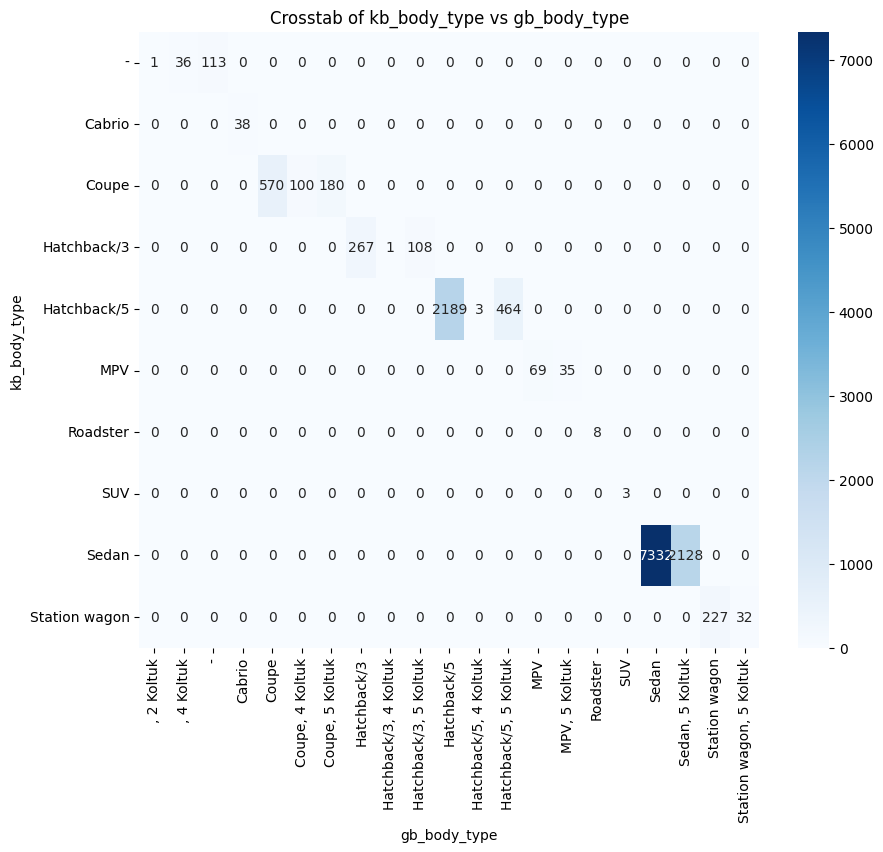

Quasi-constant columns to drop (tol=0.99): ['kb_condition', 'gb_usage_type', 'gb_is_first_owner', 'tavan_degisen', 'tavan_boyali', 'tavan_lokal', 'bagaj_degisen', 'bagaj_boyali', 'bagaj_lokal', 'fender_rl_degisen', 'fender_rr_degisen']


In [9]:

# Crosstab and Heatmap
plt.figure(figsize=(10, 8))
body_type_crosstab = pd.crosstab(df_raw['kb_body_type'], df_raw['gb_body_type'])
sns.heatmap(body_type_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('Crosstab of kb_body_type vs gb_body_type')
plt.xlabel('gb_body_type')
plt.ylabel('kb_body_type')
plt.show()

# Identify Quasi-constant features
constant_dropper = DropConstantFeatures(tol=0.99, missing_values='ignore')
constant_dropper.fit(df_raw)

print(f"Quasi-constant columns to drop (tol=0.99): {constant_dropper.features_to_drop_}")


"I am dropping the variables kb_condition, gb_usage_type, and gb_is_first_owner, while keeping the remaining features for damage scoring. Regarding body type, I will initially prioritize kb_body_type due to its more generalized structure; however, I plan to perform a LOFO (Leave-One-Feature-Out) importance analysis to finalise the selection between the two."

### Phase 1b: Numerical Feature Relationship Analysis

### Subtask:
Analyze and visualize correlations between all numerical features in `df_raw` using a heatmap.

In [10]:
print("Checking for identical columns in the dataset...")

# Dictionary to store groups of identical columns
identical_groups = {}
cols = df_raw.columns.tolist()

# Track columns already assigned to a group to avoid redundant checks
checked = set()

for i in range(len(cols)):
    col1 = cols[i]
    if col1 in checked:
        continue

    current_group = [col1]
    for j in range(i + 1, len(cols)):
        col2 = cols[j]
        if col2 in checked:
            continue

        # Check if columns are equal (pandas .equals() handles NaNs correctly)
        if df_raw[col1].equals(df_raw[col2]):
            current_group.append(col2)
            checked.add(col2)

    if len(current_group) > 1:
        identical_groups[col1] = current_group

if identical_groups:
    print("\nFound identical columns:")
    for key, group in identical_groups.items():
        print(f"  - Group: {group}")
else:
    print("\nNo perfectly identical columns found.")

Checking for identical columns in the dataset...

Found identical columns:
  - Group: ['kb_year', 'gb_year']
  - Group: ['kb_mileage', 'gb_mileage']
  - Group: ['kb_transmission', 'gb_transmission']
  - Group: ['kb_fuel', 'gb_fuel']
  - Group: ['kb_color', 'gb_color']
  - Group: ['kb_is_heavy_damaged', 'is_heavy_damaged']
  - Group: ['bagaj_degisen', 'bagaj_boyali', 'bagaj_lokal']


## Phase 2: Drop Colums and Fill the missings with group based imputation


During our initial data validation, we identified several pairs of features containing perfectly identical data across all rows (such as `kb_year` vs. `gb_year`, and `kb_transmission` vs. `gb_transmission`). These duplicates likely originate from overlapping data fields in the scraped source website (e.g., general listing specifications versus detailed technical tabs). Retaining these identical columns provides zero additional information to the predictive model and introduces perfect multicollinearity. By systematically removing one column from each duplicate pair, we streamline the feature space, reduce computational overhead, and eliminate redundant noise, ensuring our machine learning model trains more efficiently and robustly.

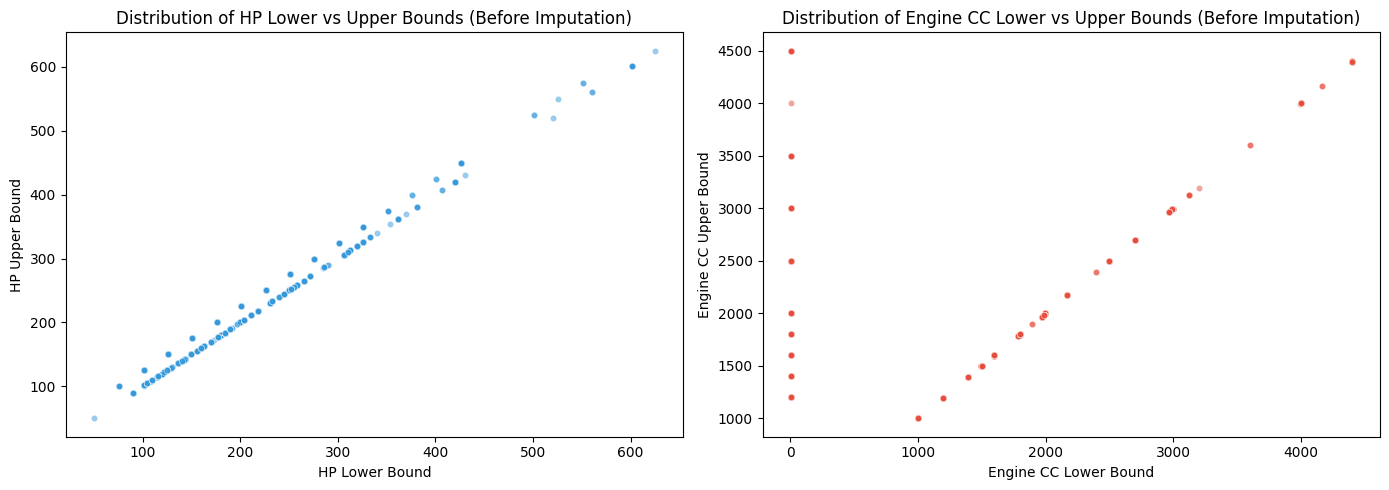

In [11]:

# hover_cols = [col for col in ['brand', 'model','gb_year'] if col in df_raw.columns]

# # 1. Plot for Horsepower
# fig_hp = px.scatter(
#     df_raw,
#     x='power_hp_low',
#     y='power_hp_up',
#     title='Distribution of HP Lower vs Upper Bounds (Before Imputation)',
#     labels={'power_hp_low': 'HP Lower Bound', 'power_hp_up': 'HP Upper Bound'},
#     opacity=0.5,
#     color_discrete_sequence=['#3498db'],
#     hover_data=hover_cols
# )
# fig_hp.update_layout(template='plotly_white')
# fig_hp.show()

# # 2. Plot for Engine CC
# fig_cc = px.scatter(
#     df_raw,
#     x='engine_cc_low',
#     y='engine_cc_up',
#     title='Distribution of Engine CC Lower vs Upper Bounds (Before Imputation)',
#     labels={'engine_cc_low': 'Engine CC Lower Bound', 'engine_cc_up': 'Engine CC Upper Bound'},
#     opacity=0.5,
#     color_discrete_sequence=['#e74c3c'],
#     hover_data=hover_cols
# )
# fig_cc.update_layout(template='plotly_white')
# fig_cc.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot for Horsepower
sns.scatterplot(data=df_raw, x='power_hp_low', y='power_hp_up',
                alpha=0.5, color='#3498db', s=20, ax=axes[0])
axes[0].set_title('Distribution of HP Lower vs Upper Bounds (Before Imputation)')
axes[0].set_xlabel('HP Lower Bound')
axes[0].set_ylabel('HP Upper Bound')

# 2. Plot for Engine CC
sns.scatterplot(data=df_raw, x='engine_cc_low', y='engine_cc_up',
                alpha=0.5, color='#e74c3c', s=20, ax=axes[1])
axes[1].set_title('Distribution of Engine CC Lower vs Upper Bounds (Before Imputation)')
axes[1].set_xlabel('Engine CC Lower Bound')
axes[1].set_ylabel('Engine CC Upper Bound')

plt.tight_layout()
plt.show()

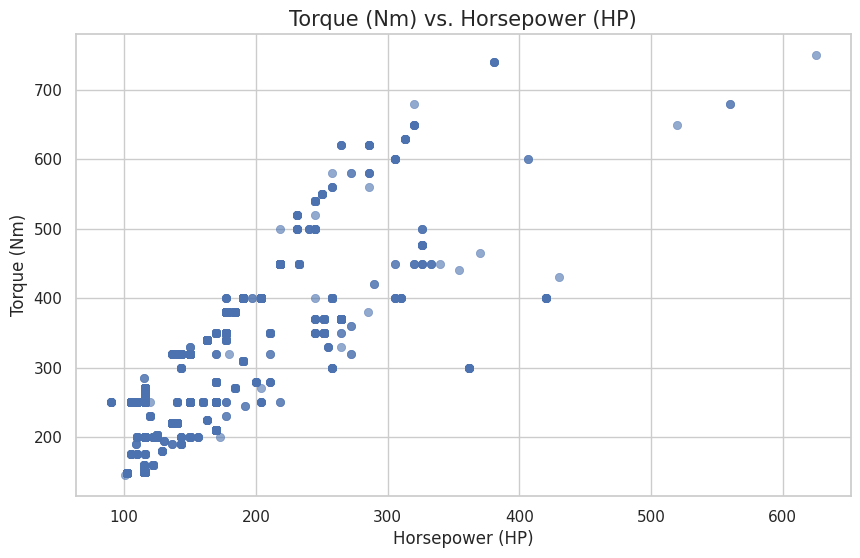


Pearson Correlation between Horsepower and Torque: 0.7623


In [12]:
# import plotly.express as px
# import pandas as pd

# # Ensure the columns exist in the DataFrame
# if 'torque_nm' in df_raw.columns and 'power_hp_val' in df_raw.columns:
#     # Create a scatter plot
#     fig = px.scatter(
#         df_raw,
#         x='power_hp_val',
#         y='torque_nm',
#         title='Torque (Nm) vs. Horsepower (HP)',
#         labels={'power_hp_val': 'Horsepower (HP)', 'torque_nm': 'Torque (Nm)','gb_year': 'year'},
#         opacity=0.6,
#         hover_data=['brand', 'series', 'model', 'price','gb_year']
#     )
#     fig.update_layout(template='plotly_white')
#     fig.show()

#     # Calculate and print the correlation
#     correlation = df_raw['power_hp_val'].corr(df_raw['torque_nm'])
#     print(f"\nPearson Correlation between Horsepower and Torque: {correlation:.4f}")
# else:
#     print("One or both of 'torque_nm' and 'power_hp_val' columns are not available in the DataFrame.")

import seaborn as sns
import matplotlib.pyplot as plt

# Sütunların varlığını kontrol et
if 'torque_nm' in df_raw.columns and 'power_hp_val' in df_raw.columns:
    # Grafik temasını ve boyutunu ayarla
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Scatter plot oluşturma
    scatter = sns.scatterplot(
        data=df_raw,
        x='power_hp_val',
        y='torque_nm',
        alpha=0.6,
        edgecolor=None
    )

    # Başlık ve etiketleri ekleme
    plt.title('Torque (Nm) vs. Horsepower (HP)', fontsize=15)
    plt.xlabel('Horsepower (HP)')
    plt.ylabel('Torque (Nm)')

    # Plotly'deki hover_data (üzerine gelince bilgi gösterme) özelliği
    # Seaborn/Matplotlib'de statik olarak mevcut değildir.

    plt.show()

    # Korelasyon hesaplama (Pandas ile devam ediyoruz)
    correlation = df_raw['power_hp_val'].corr(df_raw['torque_nm'])
    print(f"\nPearson Correlation between Horsepower and Torque: {correlation:.4f}")

else:
    print("One or both of 'torque_nm' and 'power_hp_val' columns are not available in the DataFrame.")

We are going to use upper boundary to impute `engine_cc_val`.

In [13]:
# 1. Calculate boundary means
df_raw['power_hp_val'] = df_raw[['power_hp_low', 'power_hp_up']].mean(axis=1)
df_raw['engine_cc_val'] = df_raw['engine_cc_up']

print(f"Remaining missing values in power_hp_val after boundary mean: {df_raw['power_hp_val'].isnull().sum()}")
print(f"Remaining missing values in engine_cc_val after boundary mean: {df_raw['engine_cc_val'].isnull().sum()}")

# 3. Drop quasi-constant, boundary columns, and highly correlated redundant columns
boundary_cols = ['power_hp_low', 'power_hp_up', 'engine_cc_low', 'engine_cc_up']
quasi_constant_cols = ['kb_condition', 'gb_usage_type', 'gb_is_first_owner']
info_cols = ['ad_id','listing_date','ad_title','location','power_hp_is_range','power_hp_is_range', 'description_text', 'scraped_at', 'search_date']
identical_cols = ['kb_year','kb_mileage','kb_transmission','kb_fuel','kb_color','kb_is_heavy_damaged']

cols_to_drop = list(set(quasi_constant_cols + boundary_cols + info_cols + identical_cols))
cols_to_drop = [c for c in cols_to_drop if c in df_raw.columns]

df_raw = df_raw.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns.\n")
print(f"Dataset shape after dropped features: {df_raw.shape}")

Remaining missing values in power_hp_val after boundary mean: 218
Remaining missing values in engine_cc_val after boundary mean: 185
Dropped 21 columns.

Dataset shape after dropped features: (13904, 73)


### 2b: Looking For Missing Value Patterns



--- Missing Values Heatmap ---


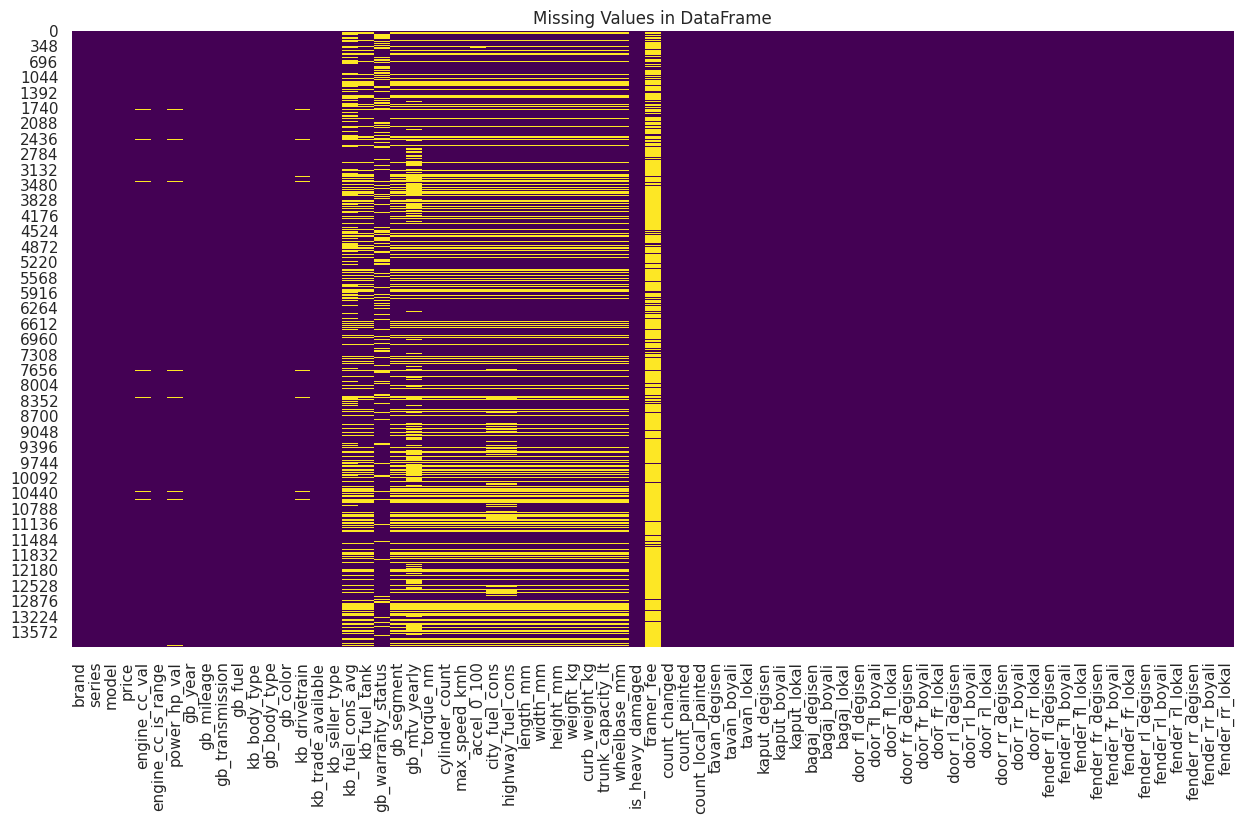

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Missing Values Heatmap ---")
plt.figure(figsize=(15, 8))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in DataFrame')
plt.show()

--- Missing Values Analysis ---

--- Top 10 Columns with Missing Values ---
                   Missing Count  Missing Percent
tramer_fee                 11778        84.709436
gb_mtv_yearly               5590        40.204258
kb_fuel_cons_avg            5435        39.089471
city_fuel_cons              4328        31.127733
highway_fuel_cons           4328        31.127733
weight_kg                   3800        27.330265
kb_fuel_tank                3784        27.215190
trunk_capacity_lt           3784        27.215190
accel_0_100                 3776        27.157652
torque_nm                   3775        27.150460


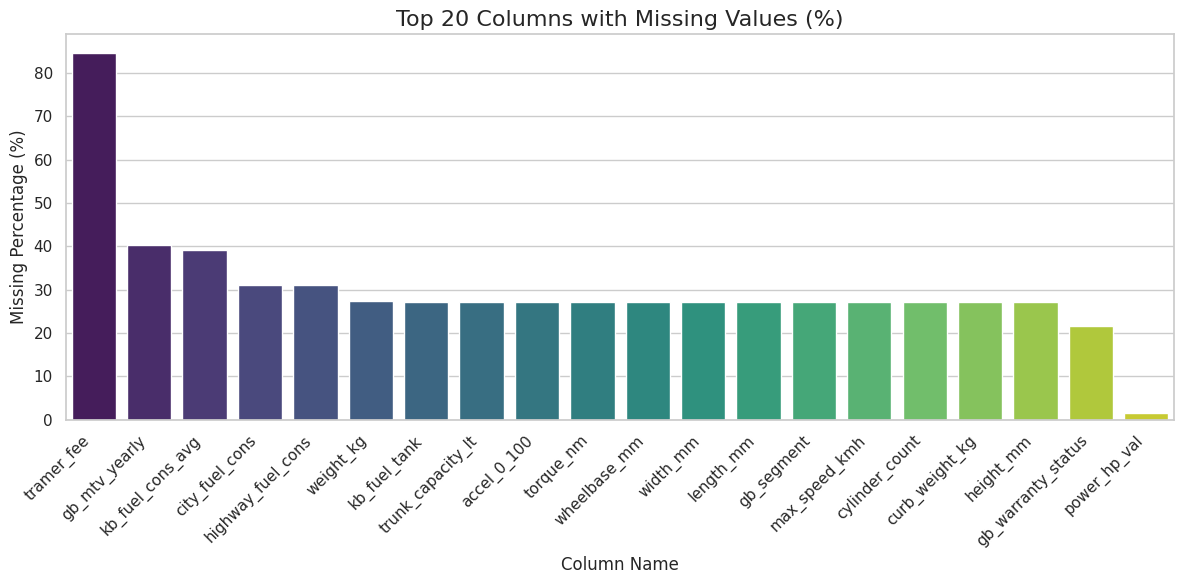

In [15]:
# print("--- Missing Values Heatmap ---")
# # Calculate missing values
# missing_values = df_raw.isnull().sum()
# missing_percent = (missing_values / len(df_raw)) * 100

# # Create a DataFrame for missing values
# missing_info = pd.DataFrame({
#     'Missing Count': missing_values,
#     'Missing Percent': missing_percent
# }).sort_values(by='Missing Percent', ascending=False)

# # Filter for columns with actual missing values
# missing_info = missing_info[missing_info['Missing Count'] > 0]

# # Print top 10 missing rates
# print("\n--- Top 10 Columns with Missing Values ---")
# print(missing_info.head(10).to_string())

# # Plotting missing values
# if not missing_info.empty:
#     fig = px.bar(
#         missing_info.head(20),
#         y='Missing Percent',
#         x=missing_info.head(20).index,
#         title='Top 20 Columns with Missing Values (% Remaining)',
#         labels={'x': 'Column Name', 'y': 'Missing Percentage'},
#         color='Missing Percent',
#         color_continuous_scale='Viridis',
#         height=500
#     )
#     fig.update_layout(xaxis={'categoryorder': 'total descending'}, template='plotly_white')
#     fig.show()
# else:
#     print("No missing values found in the dataset.")

print("--- Missing Values Analysis ---")

# Eksik değerleri hesapla (Aynı mantık)
missing_values = df_raw.isnull().sum()
missing_percent = (missing_values / len(df_raw)) * 100

# Eksik değerler için DataFrame oluştur
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent': missing_percent
}).sort_values(by='Missing Percent', ascending=False)

# Sadece eksik değeri olan sütunları filtrele
missing_info = missing_info[missing_info['Missing Count'] > 0]

# İlk 10 satırı yazdır
print("\n--- Top 10 Columns with Missing Values ---")
print(missing_info.head(10).to_string())

# Seaborn ile Görselleştirme
if not missing_info.empty:
    # Grafik boyutunu ve temasını ayarla
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # İlk 20 sütunu al
    top_20_missing = missing_info.head(20)

    # Bar plot oluşturma
    # x ekseni sütun isimleri (index), y ekseni yüzdeler
    ax = sns.barplot(
        x=top_20_missing.index,
        y=top_20_missing['Missing Percent'],
        palette='viridis' # Renk skalası
    )

    # Başlık ve etiketler
    plt.title('Top 20 Columns with Missing Values (%)', fontsize=16)
    plt.xlabel('Column Name', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)

    # X eksenindeki yazıların (sütun isimlerinin) okunabilirliği için döndürme
    plt.xticks(rotation=45, ha='right')

    # Grafik üzerine yüzde değerlerini yazdırmak istersen (Opsiyonel):
    # for p in ax.patches:
    #    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
    #                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

In [16]:
# Calculate missing values and percentages
missing_values = df_raw.isnull().sum()
missing_percent = (missing_values / len(df_raw)) * 100

# Create a DataFrame for missing information and filter for actual missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent': missing_percent
}).sort_values(by='Missing Percent', ascending=False)
missing_info = missing_info[missing_info['Missing Count'] > 0]

print("\n--- Systemic Missingness Patterns (Columns Grouped by Similar Missing %) ---")
# Group columns by rounded missing percentage to identify systemic multi-row missingness
# Rounding to 2 decimal places to catch very similar percentages
missing_groups = missing_info.groupby(missing_info['Missing Percent'].round(2))['Missing Count'].agg(
    columns=lambda x: list(missing_info.loc[x.index, 'Missing Count'].index),
    percentage='first'
)

# Sort by percentage descending
missing_groups = missing_groups.sort_values(by='percentage', ascending=False)

for percent, group_data in missing_groups.iterrows():
    # Only print groups with more than one column or if it's a very high single percentage
    if len(group_data['columns']) > 1 or percent >= 20.0:
        print(f"  Missing ~{percent:.2f}%: {group_data['columns']}")

# Also explicitly highlight the top 5 individual highest missing columns as they are clearly systemic
print("\n--- Top 5 Columns with Highest Missing Percentages (most systemic) ---")
for index, row in missing_info.head(5).iterrows():
    print(f"  - {index}: {row['Missing Percent']:.2f}% (Count: {int(row['Missing Count'])})")



--- Systemic Missingness Patterns (Columns Grouped by Similar Missing %) ---
  Missing ~84.71%: ['tramer_fee']
  Missing ~40.20%: ['gb_mtv_yearly']
  Missing ~39.09%: ['kb_fuel_cons_avg']
  Missing ~31.13%: ['city_fuel_cons', 'highway_fuel_cons']
  Missing ~27.33%: ['weight_kg']
  Missing ~27.22%: ['kb_fuel_tank', 'trunk_capacity_lt']
  Missing ~27.16%: ['accel_0_100']
  Missing ~27.15%: ['torque_nm']
  Missing ~27.14%: ['wheelbase_mm', 'width_mm', 'length_mm', 'gb_segment', 'max_speed_kmh', 'cylinder_count', 'curb_weight_kg', 'height_mm']
  Missing ~21.65%: ['gb_warranty_status']

--- Top 5 Columns with Highest Missing Percentages (most systemic) ---
  - tramer_fee: 84.71% (Count: 11778)
  - gb_mtv_yearly: 40.20% (Count: 5590)
  - kb_fuel_cons_avg: 39.09% (Count: 5435)
  - city_fuel_cons: 31.13% (Count: 4328)
  - highway_fuel_cons: 31.13% (Count: 4328)



--- Missing Values Heatmap ---


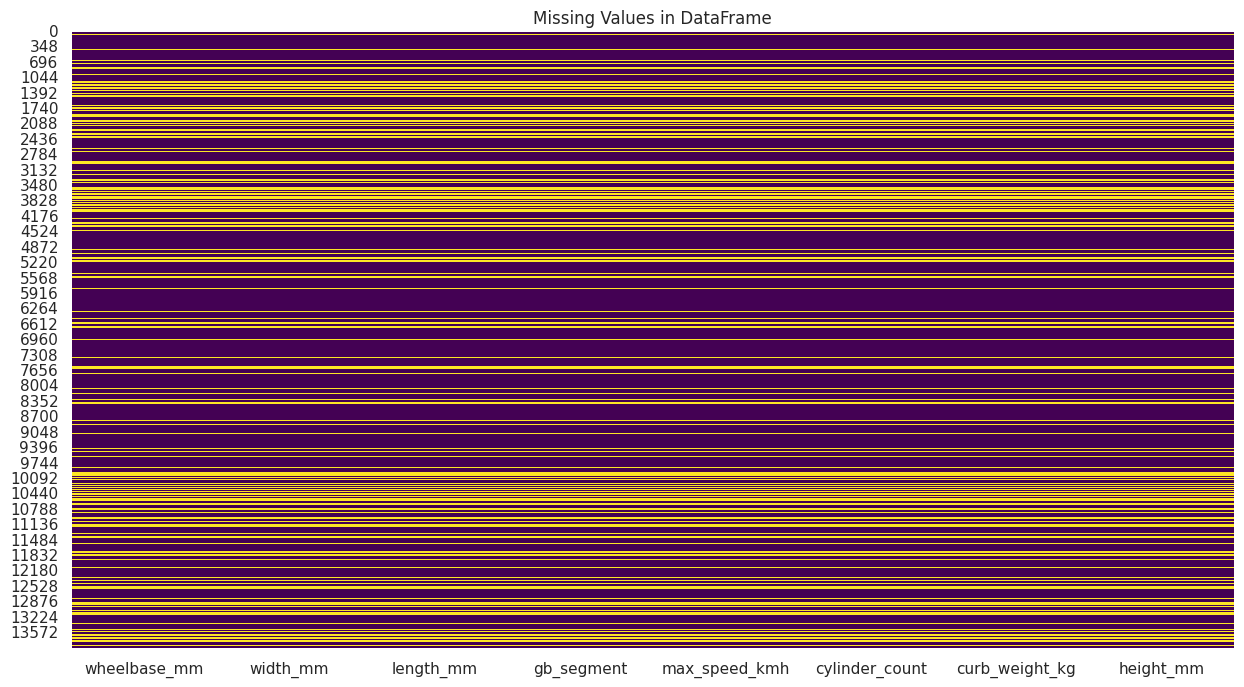

In [17]:
print("\n--- Missing Values Heatmap ---")
plt.figure(figsize=(15, 8))
sns.heatmap(df_raw[['wheelbase_mm', 'width_mm', 'length_mm', 'gb_segment', 'max_speed_kmh', 'cylinder_count', 'curb_weight_kg', 'height_mm']].isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in DataFrame')
plt.show()

Same rows are empty and when we look systemic


--- Distribution Plots for ALL Features ---

--- Numerical Feature Distributions ---


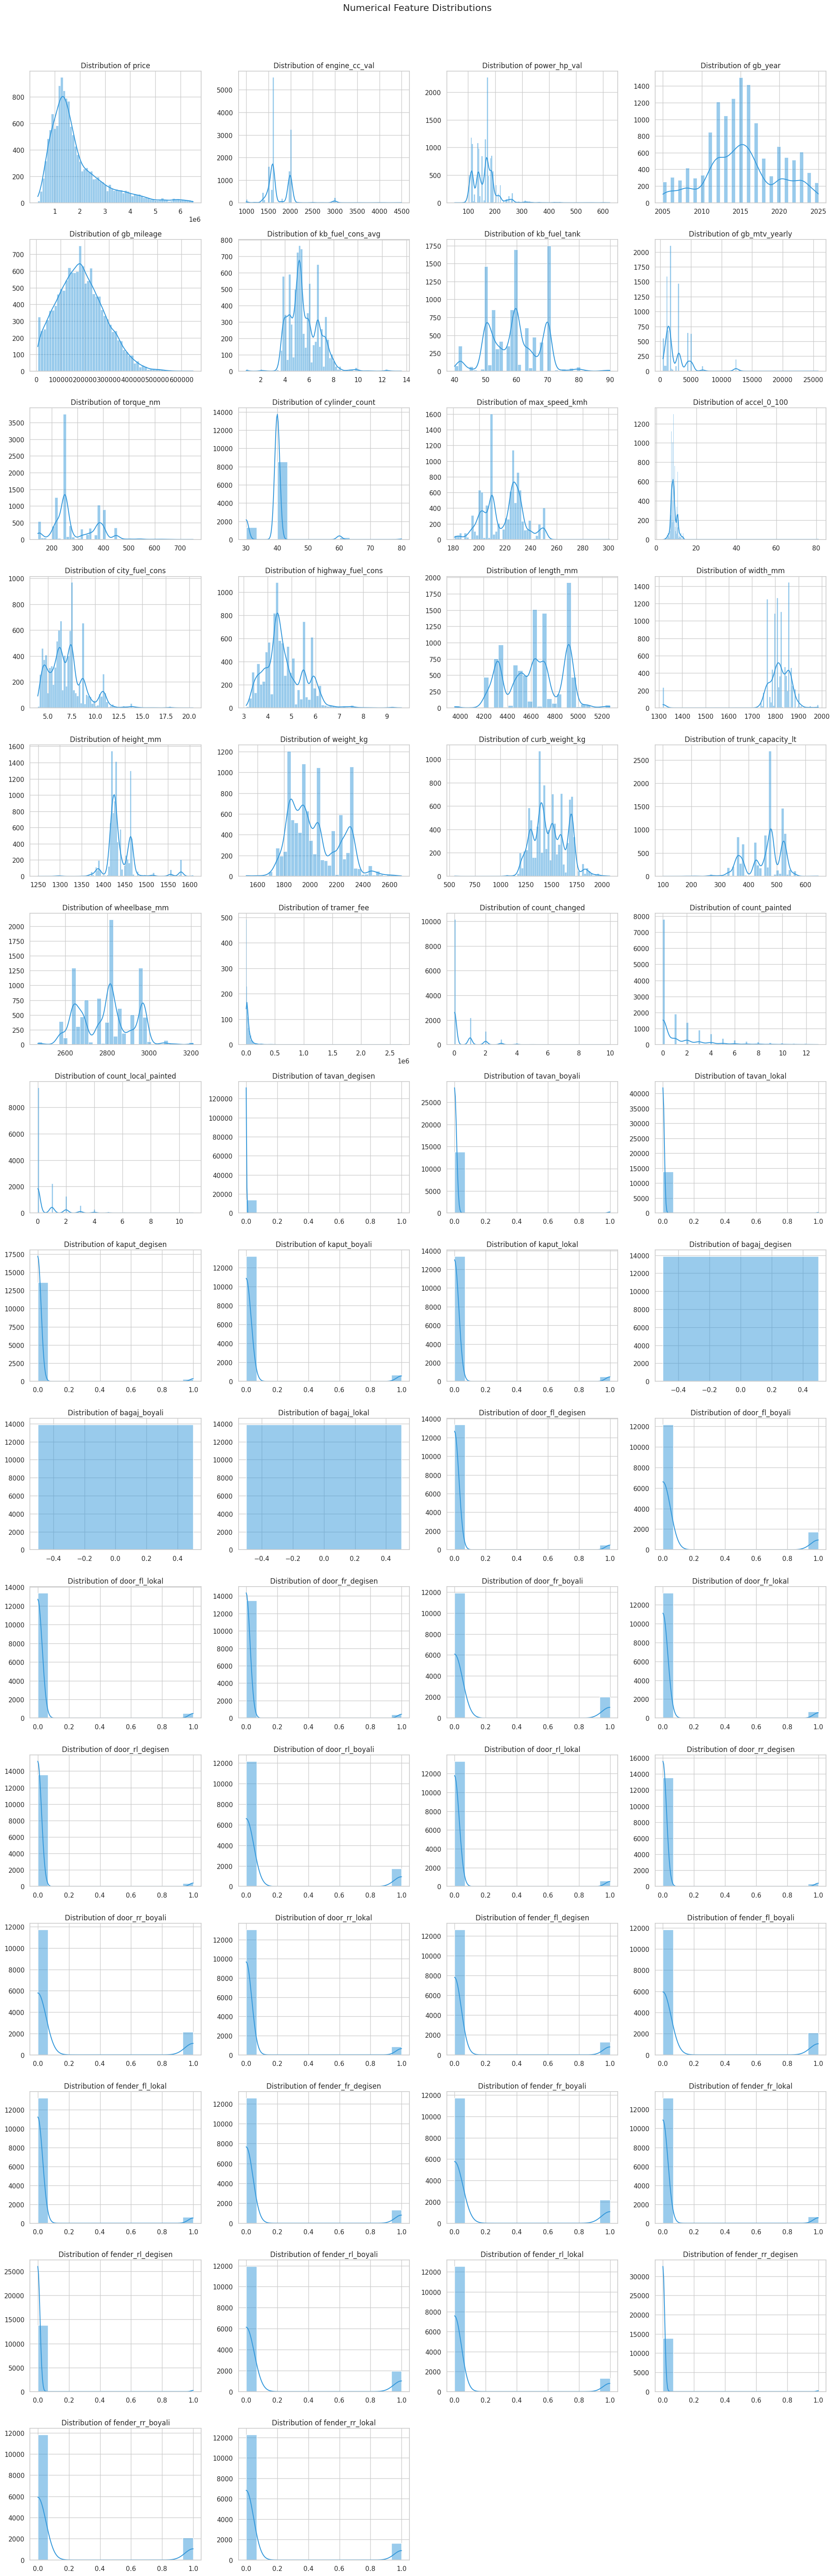


--- Categorical Feature Distributions ---


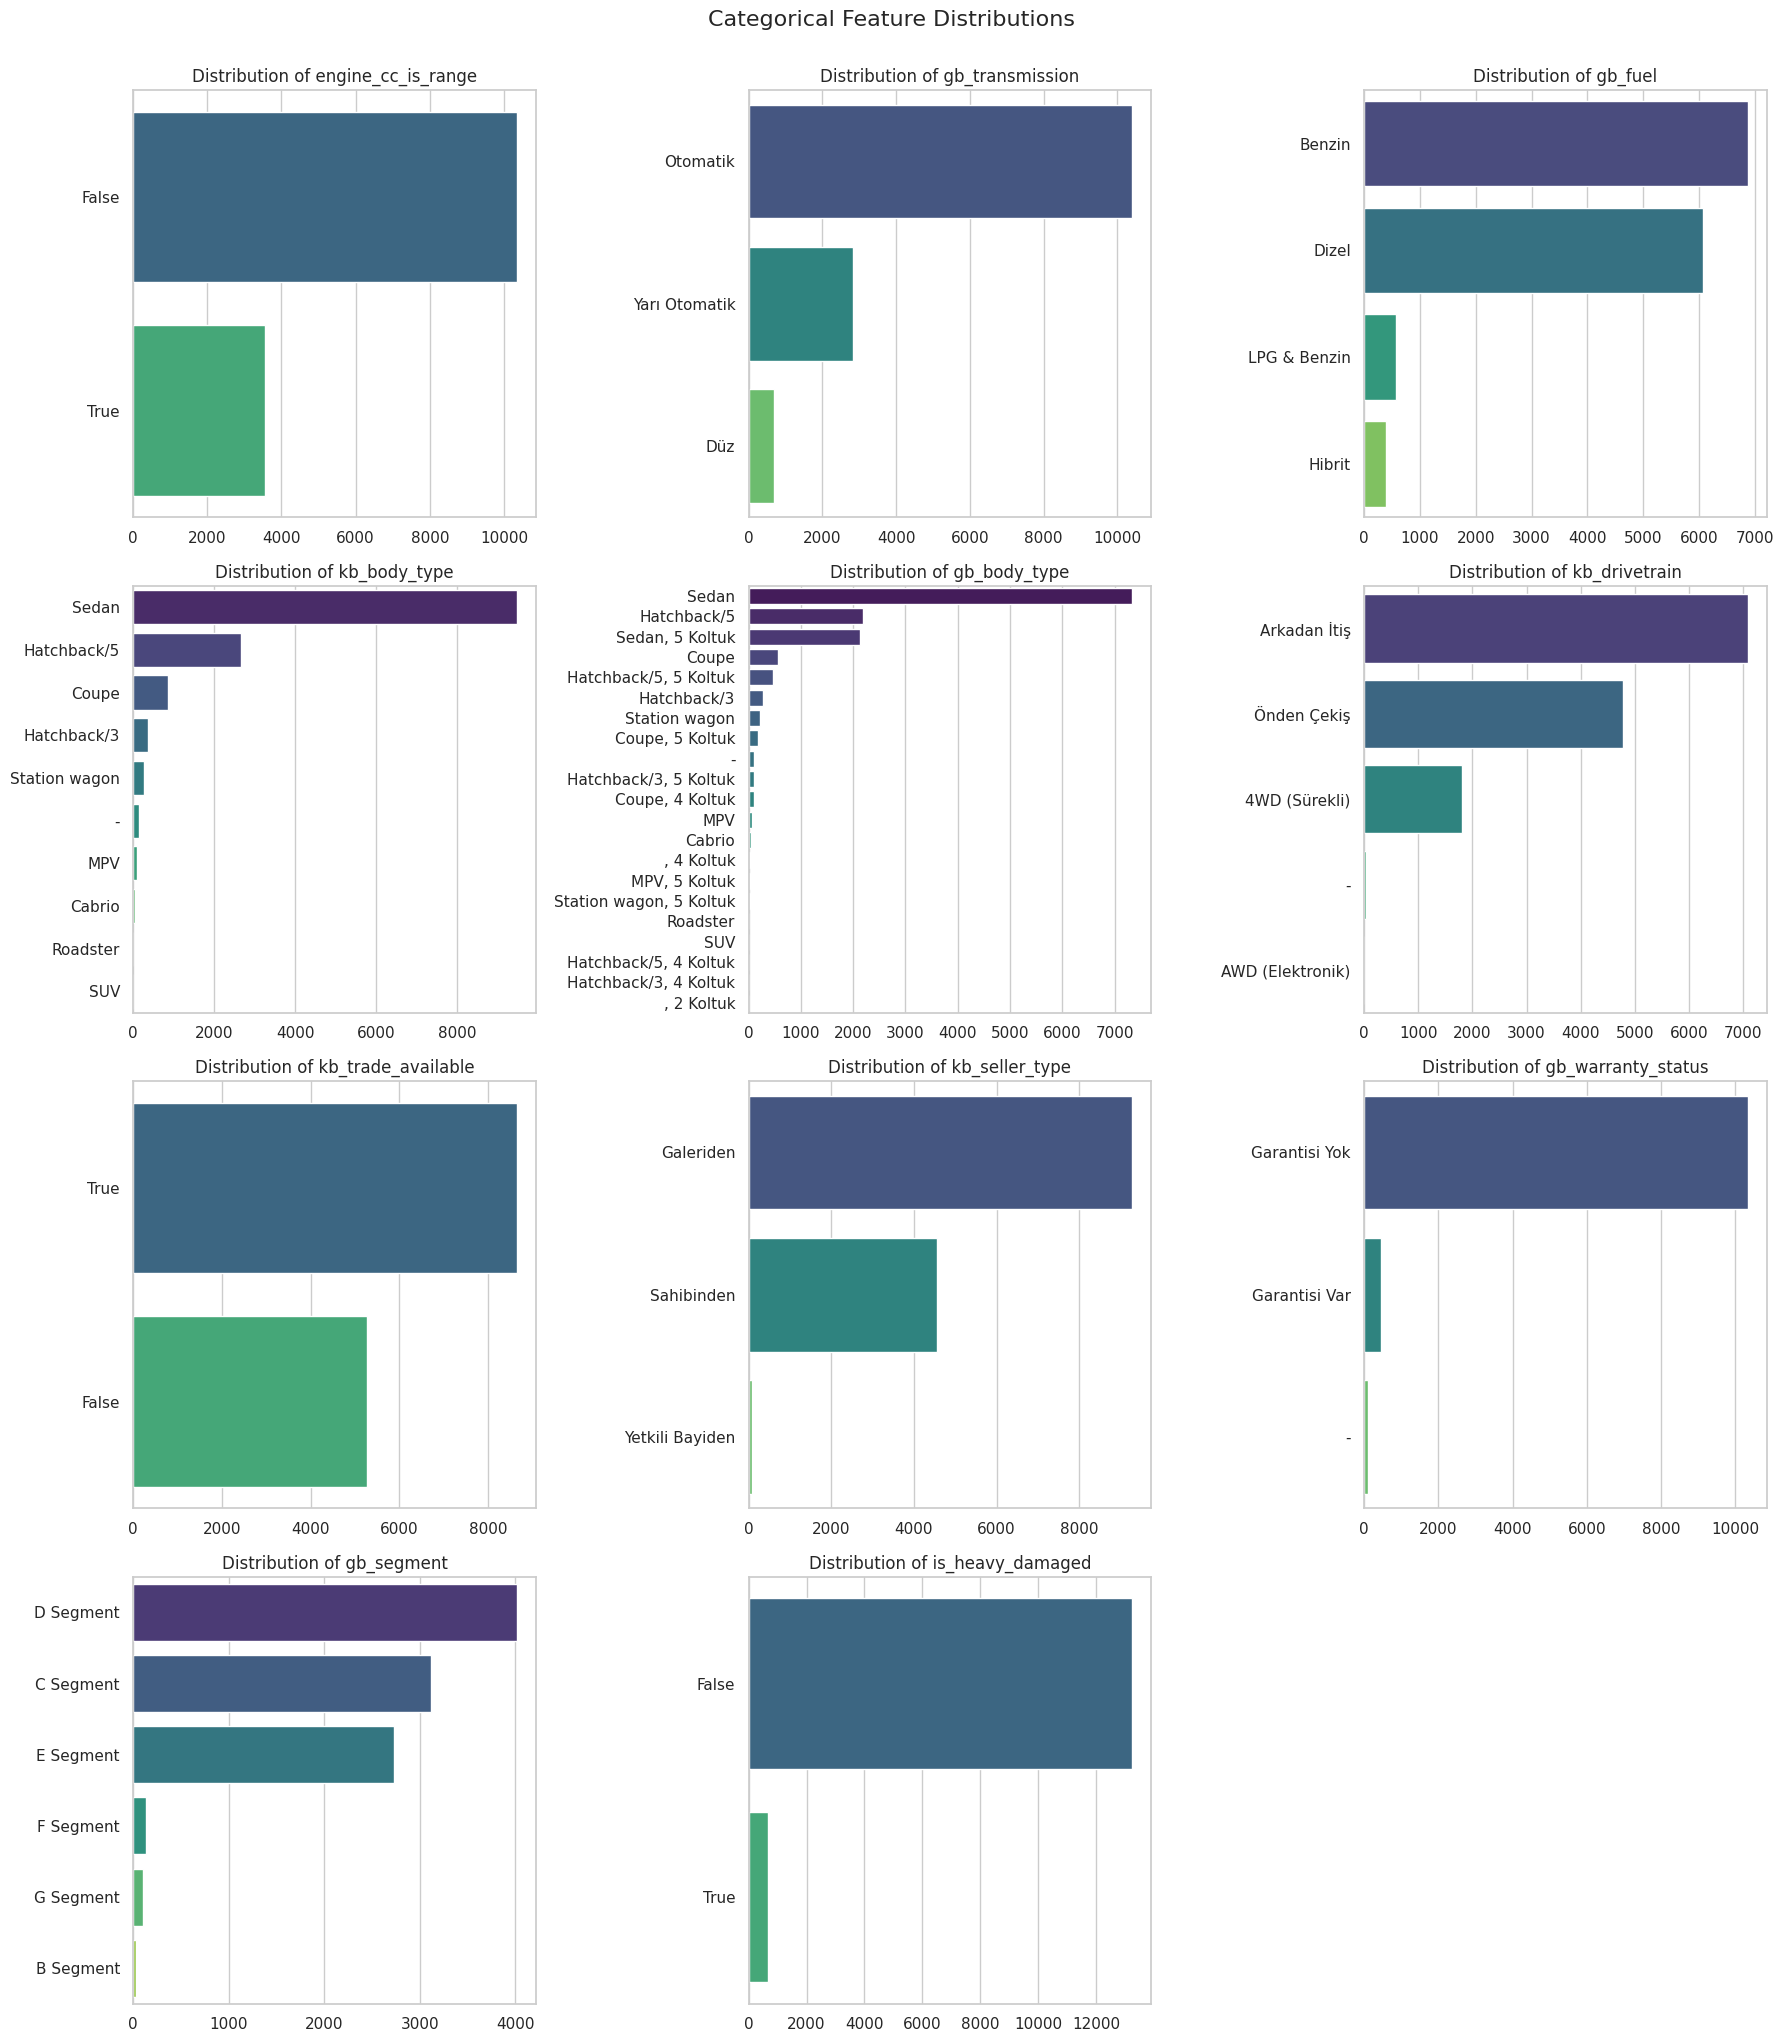

In [18]:

print("\n--- Distribution Plots for ALL Features ---")

# Identify numerical and categorical columns from df_raw
# Exclude 'price' from numerical for plotting general distributions, as it's the target
# Exclude text features like 'model' and 'series' from categorical plotting as they have too many unique values for countplot

all_num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target variable and any potential ID columns or scores that are not raw numerical features
num_features_to_plot = all_num_cols
all_cat_cols = df_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
# Exclude text features (model, series) and other high cardinality or irrelevant categorical features for countplots
cat_features_to_plot = [col for col in all_cat_cols if col not in ['model', 'series', 'brand', 'gb_color']]


# --- Plot Numerical Features ---
if num_features_to_plot:
    print("\n--- Numerical Feature Distributions ---")
    n_num = len(num_features_to_plot)
    n_cols = 4  # Number of columns for the subplot grid
    n_rows = (n_num + n_cols - 1) // n_cols # Calculate rows needed

    fig_num, axes_num = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes_num = axes_num.flatten() # Flatten for easy iteration

    for i, col in enumerate(num_features_to_plot):
        sns.histplot(df_raw[col].dropna(), kde=True, ax=axes_num[i], color='#3498db')
        axes_num[i].set_title(f'Distribution of {col}')
        axes_num[i].set_xlabel('') # Clear x-label to avoid clutter
        axes_num[i].set_ylabel('') # Clear y-label

    # Hide any unused subplots
    for j in range(i + 1, len(axes_num)):
        fig_num.delaxes(axes_num[j])

    plt.tight_layout()
    plt.suptitle('Numerical Feature Distributions', y=1.02, fontsize=16)
    plt.show()
else:
    print("No numerical features to plot.")


# --- Plot Categorical Features ---
if cat_features_to_plot:
    print("\n--- Categorical Feature Distributions ---")
    n_cat = len(cat_features_to_plot)
    n_cols = 3 # Number of columns for the subplot grid
    n_rows = (n_cat + n_cols - 1) // n_cols # Calculate rows needed

    fig_cat, axes_cat = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
    axes_cat = axes_cat.flatten() # Flatten for easy iteration

    for i, col in enumerate(cat_features_to_plot):
        sns.countplot(y=df_raw[col].dropna(), ax=axes_cat[i], order=df_raw[col].value_counts().index, palette='viridis')
        axes_cat[i].set_title(f'Distribution of {col}')
        axes_cat[i].set_xlabel('')
        axes_cat[i].set_ylabel('')

    # Hide any unused subplots
    for j in range(i + 1, len(axes_cat)):
        fig_cat.delaxes(axes_cat[j])

    plt.tight_layout()
    plt.suptitle('Categorical Feature Distributions', y=1.02, fontsize=16)
    plt.show()
else:
    print("No categorical features to plot.")

In [19]:
df_raw['cylinder_count'].value_counts()
# Covert into normal cylinder count

,count
cylinder_count,
40.0,8516
30.0,1339
60.0,245
80.0,30


In [20]:
df_raw['cylinder_count'] = df_raw['cylinder_count'] / 10

In [21]:
df_raw['cylinder_count'].value_counts()

,count
cylinder_count,
4.0,8516
3.0,1339
6.0,245
8.0,30


In [22]:

# 4. Hierarchical median imputation for numeric columns with missing values
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
cols_with_nan = [col for col in numeric_cols if df_raw[col].isnull().any()]

# Define the expanded hierarchy
hierarchy_levels = [
    (['model', 'gb_year'], 'Model & Year'),
    (['model'], 'Model'),
    (['series', 'gb_year'], 'Series & Year'),
    (['series'], 'Series'),
    (['brand', 'gb_year'], 'Brand & Year'),
    (['brand'], 'Brand')
]

for col in cols_with_nan:
    # Initialize tracking column with 'Original' for non-missing data
    df_raw[f'{col}_imputed'] = 'Original'

    for group_cols, level_name in hierarchy_levels:
        if all(c in df_raw.columns for c in group_cols):
            missing_before = df_raw[col].isnull()
            if missing_before.sum() == 0:
                continue

            # Calculate group median and fill
            df_raw[col] = df_raw.groupby(group_cols)[col].transform(lambda x: x.fillna(x.median()))

            # Find newly filled rows and update the tracker
            filled_mask = missing_before & ~df_raw[col].isnull()
            df_raw.loc[filled_mask, f'{col}_imputed'] = level_name

    # Final fallback: Overall median
    missing_before = df_raw[col].isnull()
    if missing_before.sum() > 0:
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())
        filled_mask = missing_before & ~df_raw[col].isnull()
        df_raw.loc[filled_mask, f'{col}_imputed'] = 'Overall Median'

print(f"Dataset shape after preprocessing: {df_raw.shape}")
print(f"Remaining missing values in power_hp_val overall: {df_raw['power_hp_val'].isnull().sum()}")
print(f"Remaining missing values in engine_cc_val overall: {df_raw['engine_cc_val'].isnull().sum()}")

# Show logging summary for the main columns
if 'power_hp_val_imputed' in df_raw.columns:
    print("\n--- Imputation Summary for power_hp_val ---")
    print(df_raw['power_hp_val_imputed'].value_counts())

if 'engine_cc_val_imputed' in df_raw.columns:
    print("\n--- Imputation Summary for engine_cc_val ---")
    print(df_raw['engine_cc_val_imputed'].value_counts())

Dataset shape after preprocessing: (13904, 92)
Remaining missing values in power_hp_val overall: 0
Remaining missing values in engine_cc_val overall: 0

--- Imputation Summary for power_hp_val ---
power_hp_val_imputed
Original         13686
Model & Year       167
Model               45
Series & Year        6
Name: count, dtype: int64

--- Imputation Summary for engine_cc_val ---
engine_cc_val_imputed
Original         13719
Model & Year       144
Model               35
Series & Year        6
Name: count, dtype: int64


In [23]:
# Define the hierarchy levels for mode imputation
hierarchy_levels = [
    (['model', 'gb_year'], 'Model & Year'),
    (['model'], 'Model'),
    (['series', 'gb_year'], 'Series & Year'),
    (['series'], 'Series'),
    (['brand', 'gb_year'], 'Brand & Year'),
    (['brand'], 'Brand')
]

# Columns to apply hierarchical mode imputation to
cols_to_impute = ['gb_segment', 'kb_drivetrain']

print("\n--- Applying Hierarchical Mode Imputation to specified Categorical Columns ---")
for col in cols_to_impute:
    if col not in df_raw.columns:
        print(f"  Skipping '{col}': Column not found in DataFrame.")
        continue

    print(f"  Imputing '{col}'...")
    # Create a copy to avoid SettingWithCopyWarning issues during transform
    temp_series = df_raw[col].copy()

    # Iterate through hierarchy levels for mode imputation
    for group_cols, level_name in hierarchy_levels:
        if all(c in df_raw.columns for c in group_cols):
            # Only try to fill if there are still NaNs in the temporary series
            if temp_series.isnull().any():
                # Use transform with mode. Handle cases where mode might be empty (e.g., all NaNs in group)
                filled_values = df_raw.groupby(group_cols)[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
                # Only update the temp_series for the NaNs that were actually filled by this level
                temp_series = temp_series.fillna(filled_values)

    # Final fallback: Overall mode if any NaNs still remain
    if temp_series.isnull().any():
        overall_mode = df_raw[col].mode()[0] if not df_raw[col].mode().empty else 'Unknown'
        # Fill remaining NaNs with the overall mode
        temp_series = temp_series.fillna(overall_mode)

    # Assign the imputed series back to the original DataFrame
    df_raw[col] = temp_series

print("\n--- Final Missing Values Check for Imputed Columns ---")
final_missing_check = df_raw[cols_to_impute].isnull().sum()
if final_missing_check.sum() == 0:
    print("All specified columns have been imputed successfully (no missing values remaining).")
else:
    print("Missing values still found in:")
    print(final_missing_check[final_missing_check > 0])



--- Applying Hierarchical Mode Imputation to specified Categorical Columns ---
  Imputing 'gb_segment'...
  Imputing 'kb_drivetrain'...

--- Final Missing Values Check for Imputed Columns ---
All specified columns have been imputed successfully (no missing values remaining).


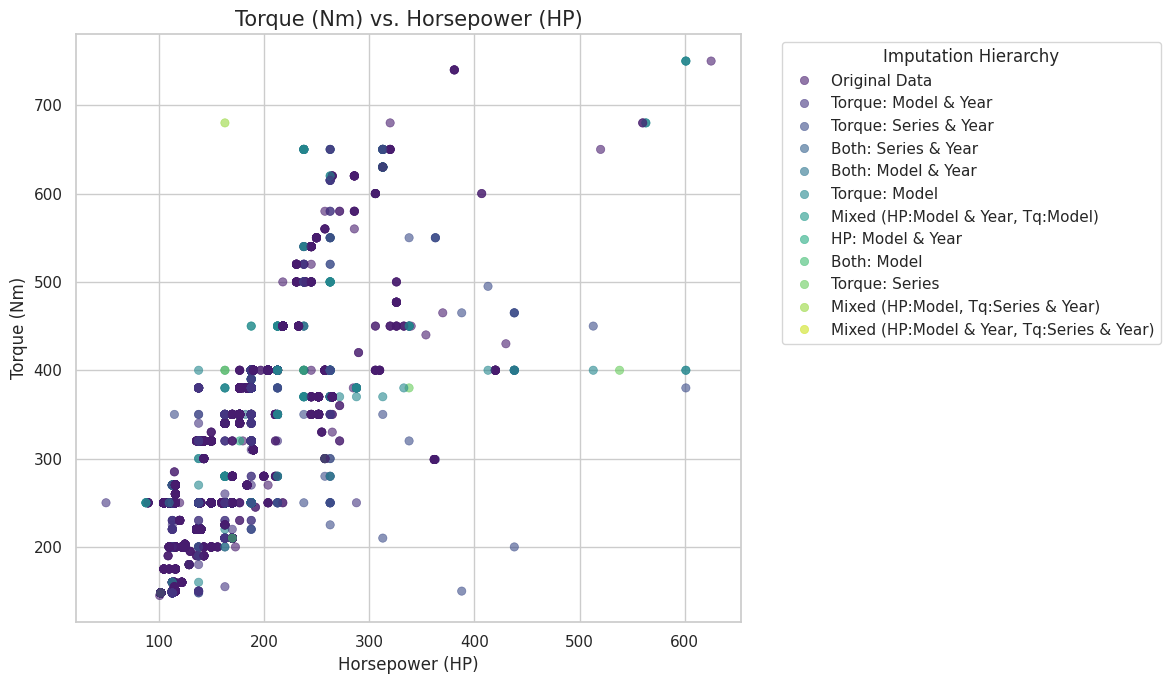


Pearson Correlation between Horsepower and Torque: 0.7414


In [24]:
# import plotly.express as px
# import pandas as pd

# # Ensure the columns exist in the DataFrame
# if 'torque_nm' in df_raw.columns and 'power_hp_val' in df_raw.columns:

#     # Create an imputation status column for the hue
#     def get_impute_status(row):
#         t_imp = str(row.get('torque_nm_imputed', 'Original'))
#         p_imp = str(row.get('power_hp_val_imputed', 'Original'))

#         if t_imp == 'Original' and p_imp == 'Original':
#             return 'Original Data'
#         elif t_imp == p_imp:
#             return f'Both: {t_imp}'
#         elif t_imp == 'Original':
#             return f'HP: {p_imp}'
#         elif p_imp == 'Original':
#             return f'Torque: {t_imp}'
#         else:
#             return f'Mixed (HP:{p_imp}, Tq:{t_imp})'

#     df_raw['imputation_status'] = df_raw.apply(get_impute_status, axis=1)

#     # Create a scatter plot
#     fig = px.scatter(
#         df_raw,
#         x='power_hp_val',
#         y='torque_nm',
#         color='imputation_status',
#         title='Torque (Nm) vs. Horsepower (HP)',
#         labels={'power_hp_val': 'Horsepower (HP)', 'torque_nm': 'Torque (Nm)','gb_year': 'year', 'imputation_status': 'Imputation Hierarchy'},
#         opacity=0.6,
#         hover_data=['brand', 'series', 'model', 'price','gb_year']
#     )
#     fig.update_layout(template='plotly_white')
#     fig.show()

#     # Calculate and print the correlation
#     correlation = df_raw['power_hp_val'].corr(df_raw['torque_nm'])
#     print(f"\nPearson Correlation between Horsepower and Torque: {correlation:.4f}")
# else:
#     print("One or both of 'torque_nm' and 'power_hp_val' columns are not available in the DataFrame.")

import seaborn as sns
import matplotlib.pyplot as plt

# Sütunların varlığını kontrol et
if 'torque_nm' in df_raw.columns and 'power_hp_val' in df_raw.columns:

    # Imputation durumunu belirleyen fonksiyon (Aynı mantık)
    def get_impute_status(row):
        t_imp = str(row.get('torque_nm_imputed', 'Original'))
        p_imp = str(row.get('power_hp_val_imputed', 'Original'))

        if t_imp == 'Original' and p_imp == 'Original':
            return 'Original Data'
        elif t_imp == p_imp:
            return f'Both: {t_imp}'
        elif t_imp == 'Original':
            return f'HP: {p_imp}'
        elif p_imp == 'Original':
            return f'Torque: {t_imp}'
        else:
            return f'Mixed (HP:{p_imp}, Tq:{t_imp})'

    df_raw['imputation_status'] = df_raw.apply(get_impute_status, axis=1)

    # Grafik ayarları
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # Seaborn Scatter Plot
    scatter = sns.scatterplot(
        data=df_raw,
        x='power_hp_val',
        y='torque_nm',
        hue='imputation_status', # Renklendirme burada yapılıyor
        alpha=0.6,
        palette='viridis',      # Renk paleti (Opsiyonel: 'tab10', 'magma' vb.)
        edgecolor=None
    )

    # Başlık ve Etiketler
    plt.title('Torque (Nm) vs. Horsepower (HP)', fontsize=15)
    plt.xlabel('Horsepower (HP)')
    plt.ylabel('Torque (Nm)')

    # Legend (Açıklama) kutusunu dışarıya veya uygun bir yere taşıma
    plt.legend(title='Imputation Hierarchy', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Korelasyon hesaplama
    correlation = df_raw['power_hp_val'].corr(df_raw['torque_nm'])
    print(f"\nPearson Correlation between Horsepower and Torque: {correlation:.4f}")

else:
    print("One or both of 'torque_nm' and 'power_hp_val' columns are not available.")

--- Top 5 Most Frequent Torque Values (The Bands) ---
torque_nm
250.0    5630
380.0    1517
220.0    1457
400.0    1214
320.0     479
Name: count, dtype: int64

--- Imputation Breakdown for these Top Bands ---
is_torque_imputed  Imputed Data  Original Data
torque_nm                                     
220.0                       203           1254
250.0                      1885           3745
320.0                       210            269
380.0                       484           1033
400.0                       317            897


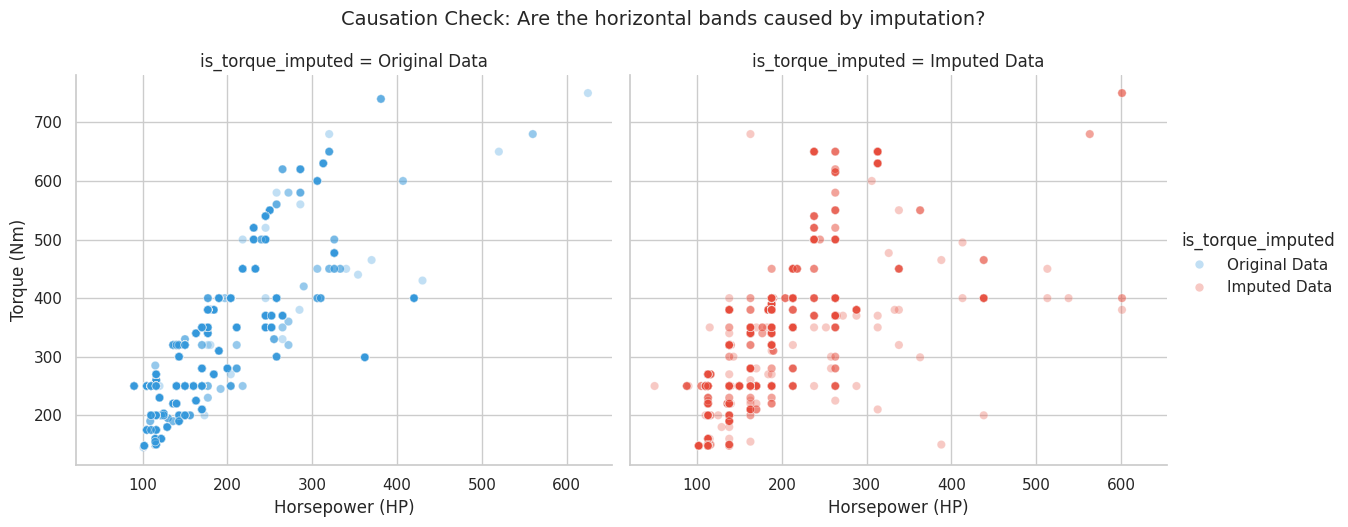

In [25]:
# import pandas as pd
# import plotly.express as px

# # Create a simplified binary flag for Torque Imputation
# df_raw['is_torque_imputed'] = df_raw['torque_nm_imputed'].apply(lambda x: 'Original Data' if str(x) == 'Original' else 'Imputed Data')

# # Analyze the most frequent Torque values (the horizontal bands)
# print("--- Top 5 Most Frequent Torque Values (The Bands) ---")
# top_torques = df_raw['torque_nm'].value_counts().head(5)
# print(top_torques)

# print("\n--- Imputation Breakdown for these Top Bands ---")
# band_analysis = df_raw[df_raw['torque_nm'].isin(top_torques.index)].groupby(['torque_nm', 'is_torque_imputed']).size().unstack(fill_value=0)
# display(band_analysis)

# # Visual proof: Side-by-side scatter plot
# fig = px.scatter(
#     df_raw,
#     x='power_hp_val',
#     y='torque_nm',
#     color='is_torque_imputed',
#     facet_col='is_torque_imputed',
#     title='Causation Check: Are the horizontal bands caused by imputation?',
#     labels={'power_hp_val': 'Horsepower (HP)', 'torque_nm': 'Torque (Nm)'},
#     opacity=0.3,
#     color_discrete_map={'Original Data': '#3498db', 'Imputed Data': '#e74c3c'}
# )
# fig.update_layout(template='plotly_white')
# fig.show()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Veri Hazırlama (Aynı mantık)
df_raw['is_torque_imputed'] = df_raw['torque_nm_imputed'].apply(
    lambda x: 'Original Data' if str(x) == 'Original' else 'Imputed Data'
)

# 2. Analiz Kısmı (Aynı mantık)
print("--- Top 5 Most Frequent Torque Values (The Bands) ---")
top_torques = df_raw['torque_nm'].value_counts().head(5)
print(top_torques)

print("\n--- Imputation Breakdown for these Top Bands ---")
band_analysis = df_raw[df_raw['torque_nm'].isin(top_torques.index)].groupby(['torque_nm', 'is_torque_imputed']).size().unstack(fill_value=0)
print(band_analysis) # 'display' yerine terminal çıktısı için 'print'

# 3. Seaborn ile Yan Yana (Facet) Scatter Plot
sns.set_theme(style="whitegrid")

# 'col' parametresi Plotly'deki 'facet_col' ile aynı işi yapar
g = sns.relplot(
    data=df_raw,
    x='power_hp_val',
    y='torque_nm',
    col='is_torque_imputed',
    hue='is_torque_imputed',
    palette={'Original Data': '#3498db', 'Imputed Data': '#e74c3c'},
    alpha=0.3,
    kind='scatter',
    height=5,
    aspect=1.2
)

# Başlık ve Etiket Düzenlemeleri
g.set_axis_labels("Horsepower (HP)", "Torque (Nm)")
g.fig.suptitle('Causation Check: Are the horizontal bands caused by imputation?', y=1.05, fontsize=14)

plt.show()

The horizontal banding at specific torque levels (e.g., 200, 250, 400 Nm) is a clear artifact of hierarcial imputation. I will not fix this it is take long take what will I do instead I am going to decide in LOFO Feature selection.

In [26]:
# Identify debug columns explicitly created for plotting
debug_cols = ['imputation_status', 'is_torque_imputed']

# Identify all imputation tracking columns (ending with '_imputed')
imputed_tracking_cols = [c for c in df_raw.columns if str(c).endswith('_imputed')]

# Combine and keep only those that actually exist in the dataframe
cols_to_drop = [c for c in (debug_cols + imputed_tracking_cols) if c in df_raw.columns]

cols_to_drop.append("engine_cc_is_range")

# Drop them
df_raw.drop(columns=cols_to_drop, inplace=True)

print(f"Removed {len(cols_to_drop)} debug variables.")
print(f"Current dataset shape: {df_raw.shape}")

Removed 23 debug variables.
Current dataset shape: (13904, 72)


## Phase 3: Domain Feature Engineering

### Subtask:
Write a fully English-documented `preprocess_damage_score` function to create an `expert_risk_score` and generate other derived features like `vehicle_age`.


**Reasoning**:
I will define the `preprocess_damage_score` function with clear English documentation, apply the requested logic to aggregate condition columns into an `expert_risk_score` and drop the original columns. Then, I will apply this function to `df_raw`, calculate `vehicle_age`, and print the summary statistics as requested.



In [27]:
import pandas as pd

def preprocess_damage_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate an aggregated 'expert_risk_score' based on the condition of various car parts
    and remove the original sparse expertise columns.

    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame containing vehicle expertise data.

    Returns:
    --------
    pd.DataFrame
        The modified DataFrame with the new 'expert_risk_score' column and without the
        original expertise condition columns.

    Details:
    --------
    Penalty points are assigned based on the severity of the damage:
    - Roof (tavan): Replaced = 150, Painted = 75, Locally Painted = 40
    - Hood (kaput): Replaced = 60, Painted = 30, Locally Painted = 15
    - Trunk (bagaj): Replaced = 40, Painted = 20, Locally Painted = 10
    - Doors (door_*): Replaced = 10, Painted = 5, Locally Painted = 2
    - Fenders (fender_*): Replaced = 8, Painted = 4, Locally Painted = 2
    """
    df_out = df.copy()

    # Identify relevant columns
    door_cols = [c for c in df_out.columns if 'door_' in c]
    fender_cols = [c for c in df_out.columns if 'fender_' in c]

    # Calculate scores using .get() with default 0 to handle missing columns gracefully
    tavan_score = (
        df_out.get('tavan_degisen', 0) * 150 +
        df_out.get('tavan_boyali', 0) * 75 +
        df_out.get('tavan_lokal', 0) * 40
    )

    kaput_score = (
        df_out.get('kaput_degisen', 0) * 60 +
        df_out.get('kaput_boyali', 0) * 30 +
        df_out.get('kaput_lokal', 0) * 15
    )

    bagaj_score = (
        df_out.get('bagaj_degisen', 0) * 40 +
        df_out.get('bagaj_boyali', 0) * 20 +
        df_out.get('bagaj_lokal', 0) * 10
    )

    doors_score = 0
    if door_cols:
        doors_degisen = df_out[[c for c in door_cols if 'degisen' in c]].sum(axis=1) if any('degisen' in c for c in door_cols) else 0
        doors_boyali = df_out[[c for c in door_cols if 'boyali' in c]].sum(axis=1) if any('boyali' in c for c in door_cols) else 0
        doors_lokal = df_out[[c for c in door_cols if 'lokal' in c]].sum(axis=1) if any('lokal' in c for c in door_cols) else 0
        doors_score = doors_degisen * 10 + doors_boyali * 5 + doors_lokal * 2

    fenders_score = 0
    if fender_cols:
        fenders_degisen = df_out[[c for c in fender_cols if 'degisen' in c]].sum(axis=1) if any('degisen' in c for c in fender_cols) else 0
        fenders_boyali = df_out[[c for c in fender_cols if 'boyali' in c]].sum(axis=1) if any('boyali' in c for c in fender_cols) else 0
        fenders_lokal = df_out[[c for c in fender_cols if 'lokal' in c]].sum(axis=1) if any('lokal' in c for c in fender_cols) else 0
        fenders_score = fenders_degisen * 8 + fenders_boyali * 4 + fenders_lokal * 2

    # Total score
    df_out['expert_risk_score'] = tavan_score + kaput_score + bagaj_score + doors_score + fenders_score

    # Clean up: Drop the original detail columns
    cols_to_drop = [
        c for c in df_out.columns
        if any(x in c for x in ['tavan_', 'kaput_', 'bagaj_', 'door_', 'fender_'])
    ]
    df_out.drop(columns=cols_to_drop, inplace=True)

    return df_out

# Apply the function to the dataset
df_raw = preprocess_damage_score(df_raw)

# Create derived feature 'vehicle_age' (assuming current year is 2024)
year_col = 'kb_year' if 'kb_year' in df_raw.columns else 'gb_year'
df_raw['vehicle_age'] = 2026 - df_raw[year_col]

# Print the results
print(f"Dataset shape after feature engineering: {df_raw.shape}")
print("\nStatistics for 'expert_risk_score' and 'vehicle_age':")
display(df_raw[['expert_risk_score', 'vehicle_age']].describe())


Dataset shape after feature engineering: (13904, 41)

Statistics for 'expert_risk_score' and 'vehicle_age':


,expert_risk_score,vehicle_age
count,13904.000000,13904.000000
mean,12.981085,10.794232
std,21.244036,4.687457
min,0.000000,1.000000
25%,0.000000,8.000000
50%,4.000000,11.000000
75%,18.000000,14.000000
max,274.000000,21.000000


### Phase 3b: Numerical Feature Relationship Analysis Part 2


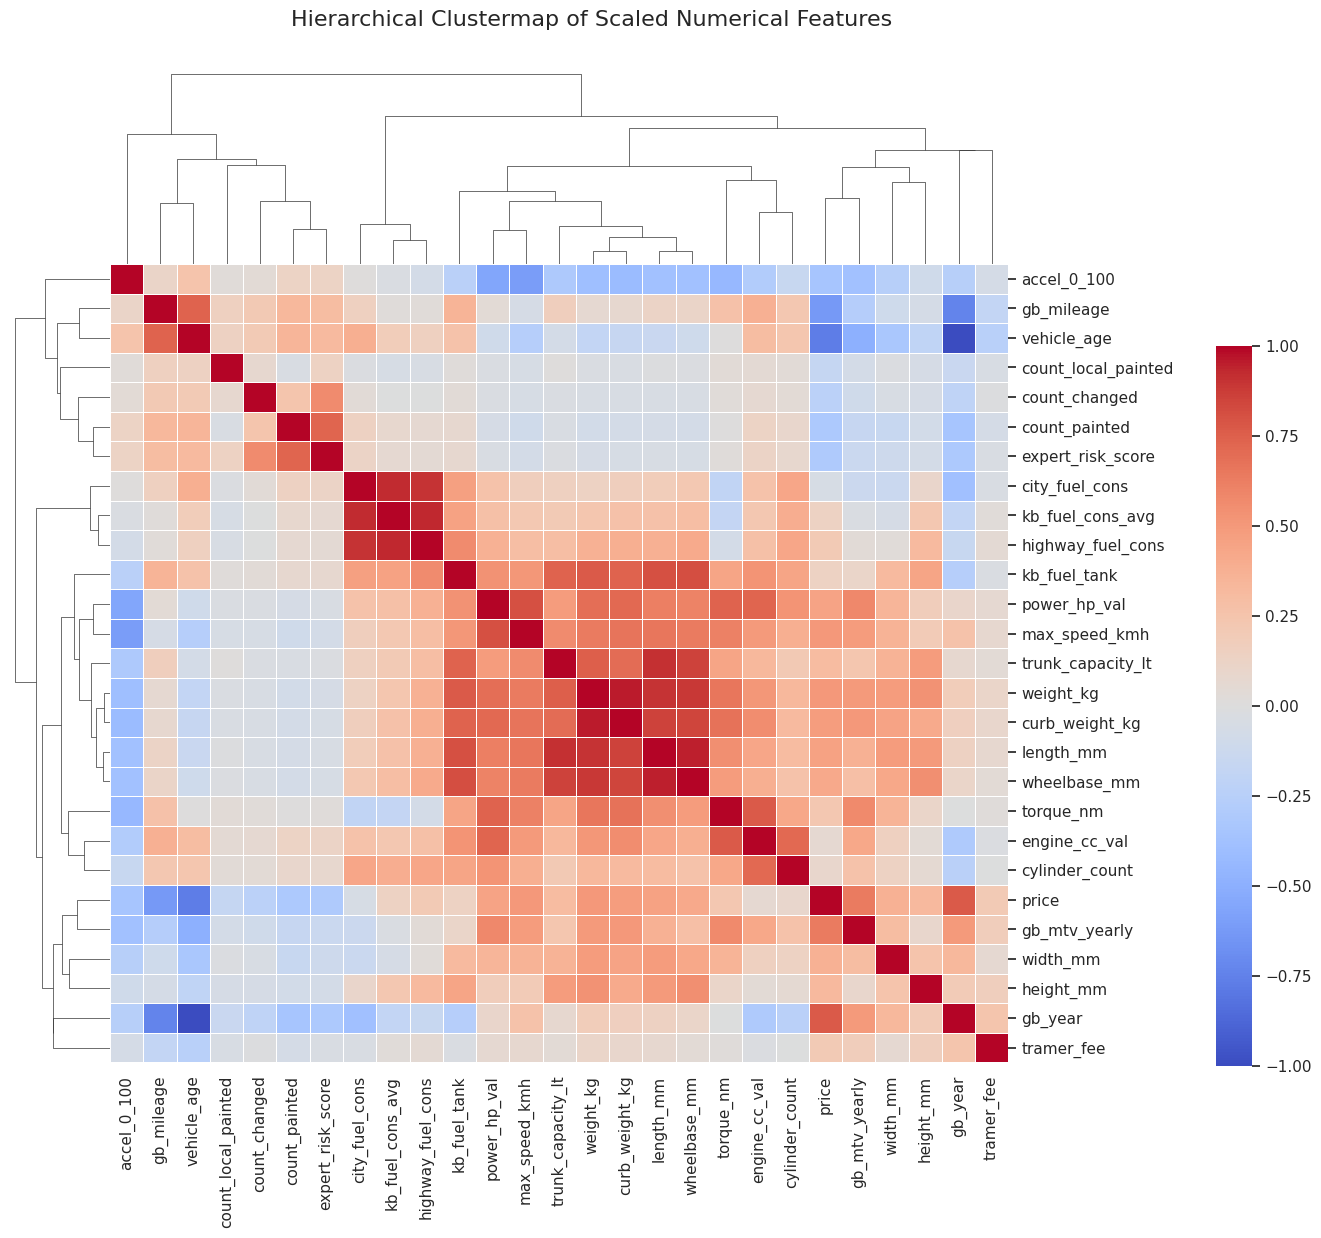

=== Multicollinearity Detection (Threshold |r| > 0.85) ===
  [!] Highly correlated: gb_year & vehicle_age (r = -1.000)
  [!] Highly correlated: weight_kg & curb_weight_kg (r = 0.953)
  [!] Highly correlated: length_mm & wheelbase_mm (r = 0.946)
  [!] Highly correlated: kb_fuel_cons_avg & highway_fuel_cons (r = 0.937)
  [!] Highly correlated: kb_fuel_cons_avg & city_fuel_cons (r = 0.924)
  [!] Highly correlated: length_mm & trunk_capacity_lt (r = 0.910)
  [!] Highly correlated: city_fuel_cons & highway_fuel_cons (r = 0.904)
  [!] Highly correlated: length_mm & weight_kg (r = 0.901)
  [!] Highly correlated: weight_kg & wheelbase_mm (r = 0.886)
  [!] Highly correlated: length_mm & curb_weight_kg (r = 0.859)
  [!] Highly correlated: trunk_capacity_lt & wheelbase_mm (r = 0.856)

=== Top 7 Features Correlated with Price ===
  - vehicle_age: -0.772
  - gb_year: +0.772
  - gb_mtv_yearly: +0.638
  - gb_mileage: -0.627
  - max_speed_kmh: +0.501
  - weight_kg: +0.500
  - curb_weight_kg: +0.482


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Select numerical columns for correlation analysis
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
# Drop identifiers if present to avoid spurious noise
features_to_plot = [c for c in numeric_cols if c not in ['ad_id']]

# 1. Scale data before calculating correlation
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_raw[features_to_plot]), columns=features_to_plot)

# Compute the correlation matrix on scaled data
corr_matrix = df_scaled.corr()

# Handle potential NaNs in the correlation matrix (can happen if a column is constant)
corr_matrix = corr_matrix.fillna(0)

# 2. Create a clustered heatmap to visualize feature clusters
clustermap = sns.clustermap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    figsize=(12, 12),
    dendrogram_ratio=(.1, .2),
    cbar_pos=(1.02, 0.15, .03, .6),
    linewidths=0.5
)
clustermap.fig.suptitle('Hierarchical Clustermap of Scaled Numerical Features', y=1.03, fontsize=16)
plt.show()

# 3. Detect Multicollinearity (exclude price)
print("=== Multicollinearity Detection (Threshold |r| > 0.85) ===")
predictor_cols = [c for c in corr_matrix.columns if c != 'price']
pred_corr = corr_matrix.loc[predictor_cols, predictor_cols]

multicollinear_pairs = []
for i in range(len(pred_corr.columns)):
    for j in range(i + 1, len(pred_corr.columns)):
        if abs(pred_corr.iloc[i, j]) > 0.85:
            multicollinear_pairs.append((pred_corr.columns[i], pred_corr.columns[j], pred_corr.iloc[i, j]))

multicollinear_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if multicollinear_pairs:
    for col1, col2, val in multicollinear_pairs:
        print(f"  [!] Highly correlated: {col1} & {col2} (r = {val:.3f})")
else:
    print("  No highly multicollinear pairs found above threshold.")

# 4. Show top correlations specifically with 'price'
if 'price' in corr_matrix.columns:
    print("\n=== Top 7 Features Correlated with Price ===")
    price_corr = corr_matrix['price'].abs().sort_values(ascending=False).drop('price').head(7)
    for col, val in price_corr.items():
        sign = "+" if corr_matrix.loc['price', col] > 0 else "-"
        print(f"  - {col}: {sign}{val:.3f}")


I will compare vehicle age and year variables in LOFO Feature Selection. We do not need just for show. Most likely the performance will be same. For capacity variables they are highly correlated. Fuel variables are highly correlated too these are expected things. I will not use these variables. These are highly missing and may be affect performance in a bad way.

### Phase 3c: Categorical Feature Relationship Analysis

=== Phase 1c: Categorical Feature Relationship Analysis ===
Computing association matrices for 14 categorical features. This might take a few seconds...


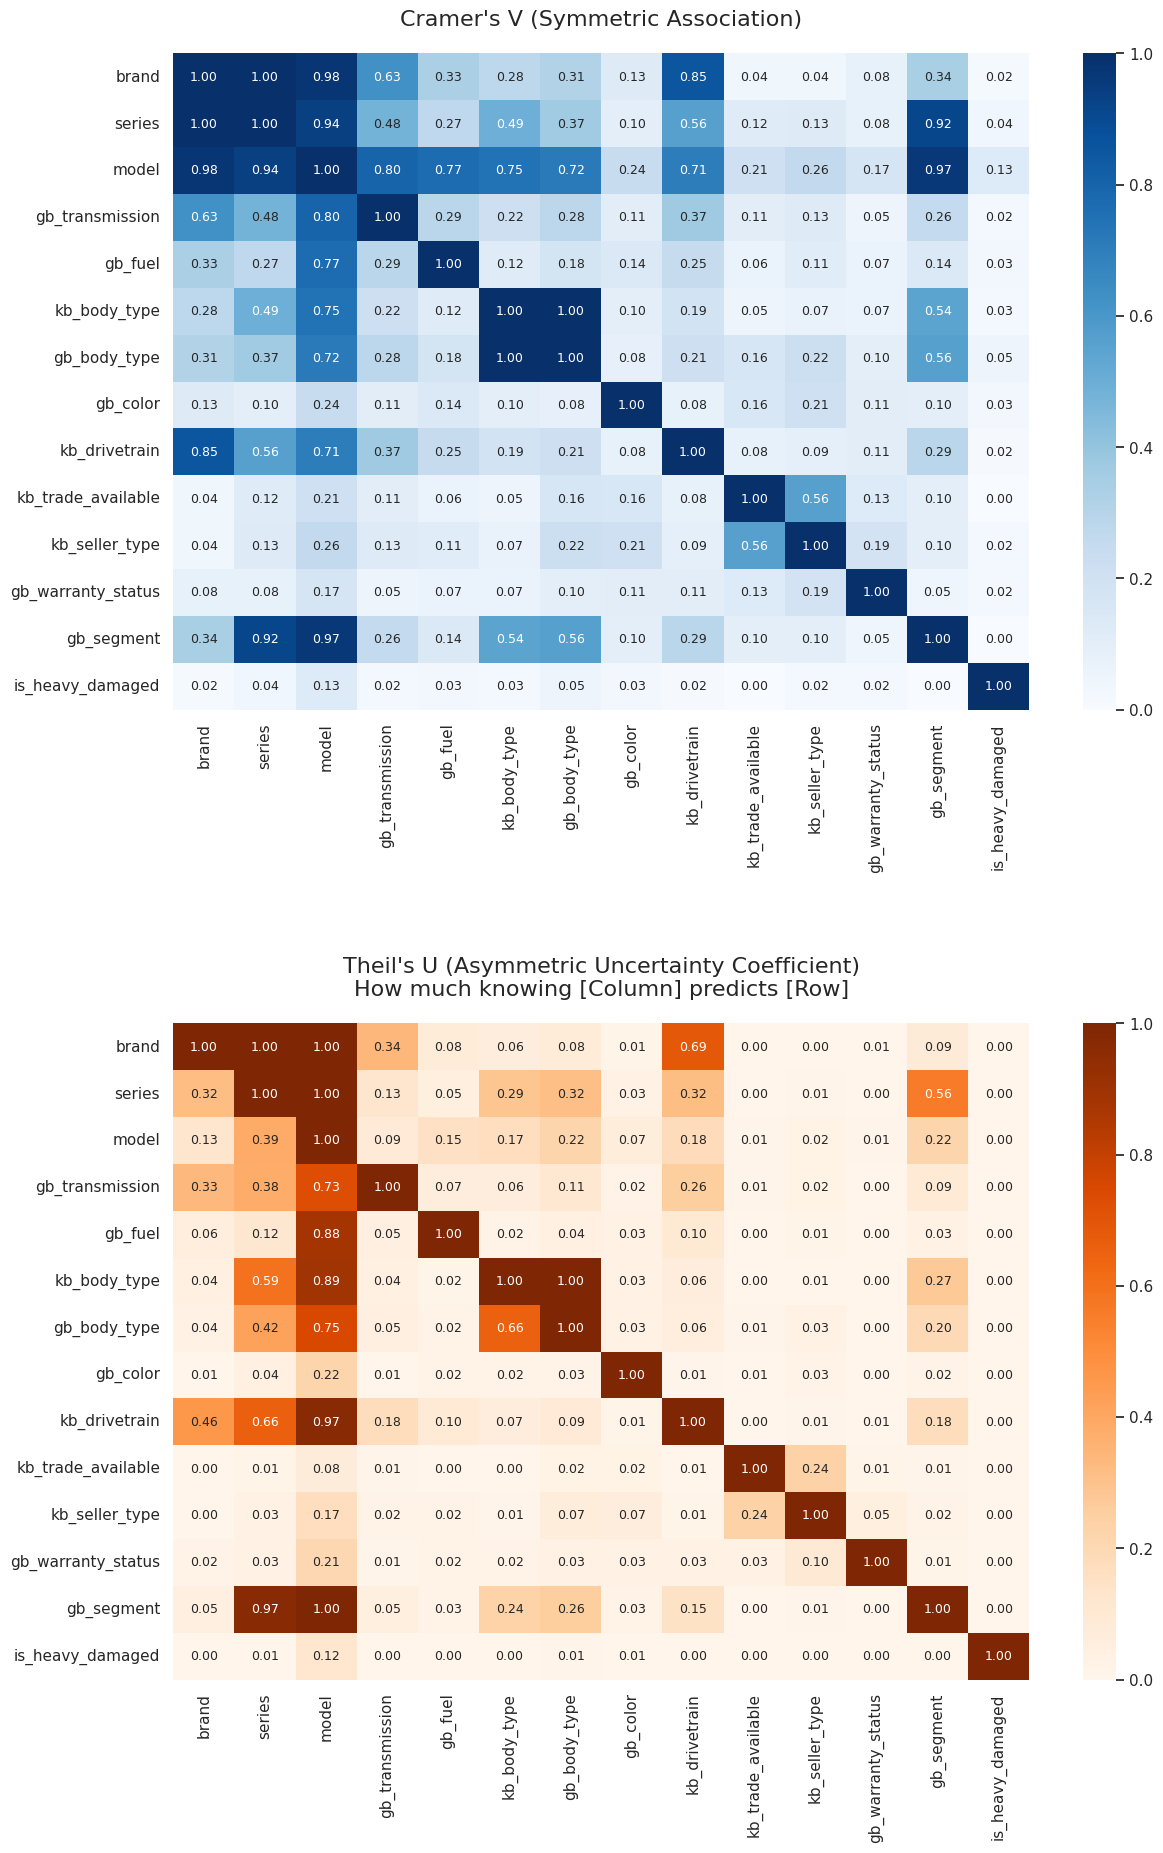


--- Interpretation ---
1. Cramer's V is a SYMMETRIC metric. It evaluates the overall correlation.
2. Theil's U is an ASYMMETRIC metric. U(Row|Column) shows how much the Column explains the Row.
3. High values (close to 1.0) indicate strong redundancy or predictive power.

=== Top Categorical Associations (Cramer's V > 0.8) ===
  - kb_body_type & gb_body_type: 1.000
  - brand & series: 0.999
  - brand & model: 0.977
  - model & gb_segment: 0.965
  - series & model: 0.941
  - series & gb_segment: 0.915
  - brand & kb_drivetrain: 0.855

=== Top Categorical Associations (Theil's U > 0.8) ===
  - Knowing 'gb_body_type' predicts 'kb_body_type': 1.000
  - Knowing 'model' predicts 'brand': 1.000
  - Knowing 'series' predicts 'brand': 1.000
  - Knowing 'model' predicts 'series': 0.999
  - Knowing 'model' predicts 'gb_segment': 0.996
  - Knowing 'series' predicts 'gb_segment': 0.972
  - Knowing 'model' predicts 'kb_drivetrain': 0.971
  - Knowing 'model' predicts 'kb_body_type': 0.891
  - Knowin

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
from sklearn.metrics import mutual_info_score

print("=== Phase 1c: Categorical Feature Relationship Analysis ===")

# Select categorical columns with a reasonable number of unique values
cat_cols = df_raw.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
exclude_cats = ['ad_title', 'description_text', 'ad_id', 'listing_date', 'scraped_at', 'search_date', 'location', 'power_hp_is_range']
# Increased the max unique values threshold from 150 to 5000 to include 'model'
cat_cols = [c for c in cat_cols if c not in exclude_cats and df_raw[c].nunique() > 1]

# Function for Cramer's V (Symmetric)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)

# Function for Theil's U / Uncertainty Coefficient (Asymmetric)
def theils_u(x, y):
    s_xy = pd.crosstab(x, y)
    pi = s_xy.sum(axis=1) / s_xy.sum().sum()
    entropy_x = ss.entropy(pi)
    if entropy_x == 0:
        return 1.0
    mis = mutual_info_score(x, y)
    return mis / entropy_x

# Calculate matrices
n_cats = len(cat_cols)
cv_matrix = pd.DataFrame(np.zeros((n_cats, n_cats)), index=cat_cols, columns=cat_cols)
tu_matrix = pd.DataFrame(np.zeros((n_cats, n_cats)), index=cat_cols, columns=cat_cols)

print(f"Computing association matrices for {n_cats} categorical features. This might take a few seconds...")
for i in range(n_cats):
    for j in range(n_cats):
        col1, col2 = cat_cols[i], cat_cols[j]
        # Drop NA to compute
        valid_idx = df_raw[[col1, col2]].dropna().index
        x = df_raw.loc[valid_idx, col1].astype(str)
        y = df_raw.loc[valid_idx, col2].astype(str)

        if i == j:
            cv_matrix.loc[col1, col2] = 1.0
            tu_matrix.loc[col1, col2] = 1.0
        else:
            cv_matrix.loc[col1, col2] = cramers_v(x, y)
            # Theil's U is asymmetric: U(x|y) - How much y explains x
            tu_matrix.loc[col1, col2] = theils_u(x, y)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 20))

# Cramer's V Heatmap
sns.heatmap(cv_matrix,
            annot=True,      # Added: Show values
            fmt=".2f",       # Added: 2 decimal places
            cmap="Blues",
            ax=axes[0],
            vmin=0,
            vmax=1,
            annot_kws={"size": 9}) # Optional: Adjust font size for clarity
axes[0].set_title("Cramer's V (Symmetric Association)", fontsize=16, pad=20)

# Theil's U Heatmap
sns.heatmap(tu_matrix,
            annot=True,      # Added: Show values
            fmt=".2f",       # Added: 2 decimal places
            cmap="Oranges",
            ax=axes[1],
            vmin=0,
            vmax=1,
            annot_kws={"size": 9}) # Optional: Adjust font size for clarity
axes[1].set_title("Theil's U (Asymmetric Uncertainty Coefficient)\nHow much knowing [Column] predicts [Row]", fontsize=16, pad=20)

plt.tight_layout(pad=5.0) # Added padding to prevent title overlap
plt.show()

# --- Interpretation ---
print("\n--- Interpretation ---")
print("1. Cramer's V is a SYMMETRIC metric. It evaluates the overall correlation.")
print("2. Theil's U is an ASYMMETRIC metric. U(Row|Column) shows how much the Column explains the Row.")
print("3. High values (close to 1.0) indicate strong redundancy or predictive power.")

# Highly Related Variables Printout
print("\n=== Top Categorical Associations (Cramer's V > 0.8) ===")
high_cv_pairs = []
for i in range(len(cv_matrix.columns)):
    for j in range(i + 1, len(cv_matrix.columns)):
        val = cv_matrix.iloc[i, j]
        if val > 0.8:
            high_cv_pairs.append((cv_matrix.columns[i], cv_matrix.columns[j], val))

high_cv_pairs.sort(key=lambda x: x[2], reverse=True)
if high_cv_pairs:
    for col1, col2, val in high_cv_pairs:
        print(f"  - {col1} & {col2}: {val:.3f}")
else:
    print("  None found.")

print("\n=== Top Categorical Associations (Theil's U > 0.8) ===")
high_tu_pairs = []
for i in range(len(tu_matrix.columns)):
    for j in range(len(tu_matrix.columns)):
        if i == j: continue
        val = tu_matrix.iloc[i, j]
        if val > 0.8:
            high_tu_pairs.append((tu_matrix.index[i], tu_matrix.columns[j], val))

high_tu_pairs.sort(key=lambda x: x[2], reverse=True)
if high_tu_pairs:
    for target, predictor, val in high_tu_pairs:
        print(f"  - Knowing '{predictor}' predicts '{target}': {val:.3f}")
else:
    print("  None found.")


In [30]:
import pandas as pd
import numpy as np
import scipy.stats as ss
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

def estimate_shannon_entropy(series):
    """Sürekli veya kategorik veri için entropi (belirsizlik) tahmini yapar."""
    # Veri sürekliyse (float/int), binning (gruplama) yaparak entropi hesapla
    if series.dtype in ['float64', 'int64']:
        # Freedman-Diaconis kuralı ile akıllı binning
        counts, _ = np.histogram(series.dropna(), bins='fd')
    else:
        counts = series.value_counts()

    probs = counts / counts.sum()
    return ss.entropy(probs)

def calculate_redundancy(df, target_col, features):
    results = []

    # Hedef (Model) için sayısal dönüşüm
    target_encoded = df[target_col].astype('category').cat.codes

    for col in features:
        # Boş değerleri temizle
        valid_data = df[[col, target_col]].dropna()
        x = valid_data[col]
        y = valid_data[target_col].astype('category').cat.codes

        # 1. Özelliğin Kendi Entropisi (H(X)) - Toplam Belirsizlik
        h_x = estimate_shannon_entropy(x)

        # 2. Karşılıklı Bilgi (I(X;Y))
        # Kategorik ise classif, sürekli ise regression tabanlı MI kullan
        if x.dtype in ['float64', 'int64']:
            # Model (y) kategorik olduğu için discrete_features=True diyoruz
            mi = mutual_info_regression(x.values.reshape(-1, 1), y, random_state=42)[0]
        else:
            x_enc = x.astype('category').cat.codes
            mi = mutual_info_classif(x_enc.values.reshape(-1, 1), y, random_state=42)[0]

        # 3. Bilgi Artıklığı Oranı (Redundancy %)
        # Model bilgisi, özelliğin belirsizliğini ne oranda açıklıyor?
        redundancy_pct = (mi / h_x) * 100 if h_x > 0 else 0

        results.append({
            'Feature': col,
            'Entropy (Total Uncertainty)': h_x,
            'Mutual Info with Model': mi,
            'Redundancy (%)': min(redundancy_pct, 100.0) # 100'ü aşamaz
        })

    return pd.DataFrame(results).sort_values(by='Redundancy (%)', ascending=False)

# --- Uygulama ---
features_to_test = ['wheelbase_mm', 'width_mm', 'length_mm', 'gb_segment',
                   'max_speed_kmh', 'cylinder_count', 'curb_weight_kg', 'height_mm']

redundancy_df = calculate_redundancy(df_raw, 'model', features_to_test)

print("=== Bilgi Artıklığı Analizi (Model Sütununa Göre) ===")
print(redundancy_df.to_string(index=False))

# Karar Önerisi
print("\n--- Yorum ve Karar ---")
for _, row in redundancy_df.iterrows():
    if row['Redundancy (%)'] > 90:
        print(f" - [{row['Feature']}]: %{row['Redundancy (%)']:.1f} Artık. MODEL içinde zaten var, ÇIKARILABİLİR.")
    elif row['Redundancy (%)'] > 70:
        print(f" - [{row['Feature']}]: %{row['Redundancy (%)']:.1f} Yüksek Bağlılık. İncele ve tutmayı düşün.")
    else:
        print(f" - [{row['Feature']}]: %{row['Redundancy (%)']:.1f} Özgün Bilgi. Veri setinde kalsın.")

=== Bilgi Artıklığı Analizi (Model Sütununa Göre) ===
       Feature  Entropy (Total Uncertainty)  Mutual Info with Model  Redundancy (%)
  wheelbase_mm                     2.597758                2.707323      100.000000
      width_mm                     2.831880                2.865687      100.000000
     length_mm                     2.575656                3.223208      100.000000
    gb_segment                     1.195644                1.467208      100.000000
curb_weight_kg                     3.206310                3.422261      100.000000
     height_mm                     2.870829                2.829981       98.577158
 max_speed_kmh                     2.977917                2.742922       92.108745
cylinder_count                     0.000000                0.467000        0.000000

--- Yorum ve Karar ---
 - [wheelbase_mm]: %100.0 Artık. MODEL içinde zaten var, ÇIKARILABİLİR.
 - [width_mm]: %100.0 Artık. MODEL içinde zaten var, ÇIKARILABİLİR.
 - [length_mm]: %100.0 Art

## Phase 4: Cross-Validation & Baseline Modeling

### Subtask:
Set up a cross-validation framework and train a GPU-accelerated CatBoost baseline model using the 'model' column as a text feature.


**Reasoning**:
I will prepare the dataset by removing non-predictive columns, define the target variable as the log of the price, handle missing values in categorical/text columns, and set up a 5-fold cross-validation loop to train and evaluate the GPU-accelerated CatBoost baseline model.



In [31]:
df_raw.columns

Index(['brand', 'series', 'model', 'price', 'engine_cc_val', 'power_hp_val',
       'gb_year', 'gb_mileage', 'gb_transmission', 'gb_fuel', 'kb_body_type',
       'gb_body_type', 'gb_color', 'kb_drivetrain', 'kb_trade_available',
       'kb_seller_type', 'kb_fuel_cons_avg', 'kb_fuel_tank',
       'gb_warranty_status', 'gb_segment', 'gb_mtv_yearly', 'torque_nm',
       'cylinder_count', 'max_speed_kmh', 'accel_0_100', 'city_fuel_cons',
       'highway_fuel_cons', 'length_mm', 'width_mm', 'height_mm', 'weight_kg',
       'curb_weight_kg', 'trunk_capacity_lt', 'wheelbase_mm',
       'is_heavy_damaged', 'tramer_fee', 'count_changed', 'count_painted',
       'count_local_painted', 'expert_risk_score', 'vehicle_age'],
      dtype='object')

In [32]:
print("\n--- Checking for empty categories (missing values in categorical columns) ---")
cat_cols = df_raw.select_dtypes(include=['object', 'category', 'bool']).columns
missing_cat_counts = df_raw[cat_cols].isnull().sum()

if missing_cat_counts.sum() == 0:
    print("No empty categories (missing values) found in categorical columns after imputation.")
else:
    print("Remaining empty categories (missing values) in categorical columns:")
    print(missing_cat_counts[missing_cat_counts > 0])

print("\n--- How CatBoost handles null categories ---")
print("CatBoost treats missing values in categorical features as a special, distinct category.")
print("It learns during training whether these 'missing' values should be grouped with other categories or form their own group for optimal splits.")
print("This means you generally do not need to explicitly impute missing values in categorical columns before training with CatBoost, as it handles them intelligently internally.")



--- Checking for empty categories (missing values in categorical columns) ---
Remaining empty categories (missing values) in categorical columns:
gb_warranty_status    3010
dtype: int64

--- How CatBoost handles null categories ---
CatBoost treats missing values in categorical features as a special, distinct category.
It learns during training whether these 'missing' values should be grouped with other categories or form their own group for optimal splits.
This means you generally do not need to explicitly impute missing values in categorical columns before training with CatBoost, as it handles them intelligently internally.


In [33]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool

# 1. Prepare dataset
target_col = 'price'
drop_cols = [target_col]
drop_cols = [c for c in drop_cols if c in df_raw.columns]

# Drop rows where target is missing or zero
df_model = df_raw.dropna(subset=[target_col]).copy()
df_model = df_model[df_model[target_col] > 0]

X = df_model.drop(columns=drop_cols)
y = df_model[target_col]

# 2. Handle categorical and text features
text_features = ['model'] if 'model' in X.columns else []
cat_features_all = [col for col in X.select_dtypes(include=['object', 'category', 'bool']).columns if col not in text_features]

# Fill missing values for categorical and text columns with 'missing'
for col in cat_features_all + text_features:
    X[col] = X[col].fillna('missing').astype(str)

# 3. Define 2x2 combinations for Year/Age and KB/GB Body Types
configs = [
    {"name": "vehicle_age + kb_body_type", "drop": ["gb_year", "gb_body_type"]},
    {"name": "vehicle_age + gb_body_type", "drop": ["gb_year", "kb_body_type"]},
    {"name": "gb_year + kb_body_type",     "drop": ["vehicle_age", "gb_body_type"]},
    {"name": "gb_year + gb_body_type",     "drop": ["vehicle_age", "kb_body_type"]},
]

# Pre-build feature sets and indices
datasets = {}
for cfg in configs:
    cols_to_drop = [c for c in cfg["drop"] if c in X.columns]
    X_cfg = X.drop(columns=cols_to_drop)

    c_feats = [c for c in cat_features_all if c in X_cfg.columns]
    t_feats = [c for c in text_features if c in X_cfg.columns]

    datasets[cfg["name"]] = {
        "X": X_cfg,
        "c_idx": [X_cfg.columns.get_loc(c) for c in c_feats],
        "t_idx": [X_cfg.columns.get_loc(c) for c in t_feats],
        "scores": []
    }

# 4. Establish cross-validation framework
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Starting 5-fold Cross-Validation with CatBoost (GPU) for 2x2 combinations...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n--- Fold {fold + 1} ---")

    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    for cfg_name, data in datasets.items():
        X_train, X_val = data["X"].iloc[train_idx], data["X"].iloc[val_idx]

        train_pool = Pool(data=X_train, label=y_train, cat_features=data["c_idx"], text_features=data["t_idx"])
        val_pool = Pool(data=X_val, label=y_val, cat_features=data["c_idx"], text_features=data["t_idx"])

        model = CatBoostRegressor(
            iterations=1000, learning_rate=0.05, depth=6,
            loss_function='RMSE', eval_metric='RMSE',
            early_stopping_rounds=100, verbose=False,
            random_seed=42, **gpu_params
        )
        model.fit(train_pool, eval_set=val_pool)

        preds = model.predict(val_pool)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        data["scores"].append(rmse)

        print(f"  {cfg_name:30s} RMSE : {rmse:.4f}")

print("\n=== FINAL COMPARISON (Mean CV RMSE) ===")
for cfg_name, data in datasets.items():
    mean_rmse = np.mean(data["scores"])
    std_rmse = np.std(data["scores"])
    print(f"{cfg_name:30s} : {mean_rmse:.4f} (±{std_rmse:.4f})")

Starting 5-fold Cross-Validation with CatBoost (GPU) for 2x2 combinations...

--- Fold 1 ---
  vehicle_age + kb_body_type     RMSE : 194203.8777
  vehicle_age + gb_body_type     RMSE : 194190.9607
  gb_year + kb_body_type         RMSE : 193190.8369
  gb_year + gb_body_type         RMSE : 192402.1037

--- Fold 2 ---
  vehicle_age + kb_body_type     RMSE : 193917.3367
  vehicle_age + gb_body_type     RMSE : 193861.2270
  gb_year + kb_body_type         RMSE : 193329.4420
  gb_year + gb_body_type         RMSE : 193920.6988

--- Fold 3 ---
  vehicle_age + kb_body_type     RMSE : 179982.0014
  vehicle_age + gb_body_type     RMSE : 179724.9643
  gb_year + kb_body_type         RMSE : 178079.4357
  gb_year + gb_body_type         RMSE : 178011.3103

--- Fold 4 ---
  vehicle_age + kb_body_type     RMSE : 195770.9350
  vehicle_age + gb_body_type     RMSE : 196586.5364
  gb_year + kb_body_type         RMSE : 195930.1660
  gb_year + gb_body_type         RMSE : 197363.5721

--- Fold 5 ---
  vehicle_a

In [34]:
print("Dropping 'gb_body_type' and 'vehicle_age' to finalize the feature set...")
cols_to_drop_final = ['gb_body_type', 'vehicle_age']
X = X.drop(columns=[c for c in cols_to_drop_final if c in X.columns])

# Assign text and cat features to variables for the next steps
text_features = ['model'] if 'model' in X.columns else []
cat_features = [col for col in X.select_dtypes(include=['object', 'category', 'bool']).columns if col not in text_features]

# Get integer indices for CatBoost
cat_indices = [X.columns.get_loc(col) for col in cat_features]
text_indices = [X.columns.get_loc(col) for col in text_features]

print(f"\nFinal feature count: {X.shape[1]}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Text features ({len(text_features)}): {text_features}")

Dropping 'gb_body_type' and 'vehicle_age' to finalize the feature set...

Final feature count: 38
Categorical features (12): ['brand', 'series', 'gb_transmission', 'gb_fuel', 'kb_body_type', 'gb_color', 'kb_drivetrain', 'kb_trade_available', 'kb_seller_type', 'gb_warranty_status', 'gb_segment', 'is_heavy_damaged']
Text features (1): ['model']


## Phase 5: Outlier Analysis

### Subtask:
Perform anomaly detection using Z-Scores on CatBoost residuals and Isolation Forest. Consolidate the flags into a single decision DataFrame and create an interactive Plotly chart showing which car `model`s are most frequently flagged as outliers.

In [35]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
import plotly.express as px

# 1. Get CatBoost residuals on the full dataset
full_pool = Pool(data=X, label=y, cat_features=cat_indices, text_features=text_indices)
baseline_full = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=False,
    random_seed=42,
    **gpu_params
)
baseline_full.fit(full_pool)
preds_full = baseline_full.predict(full_pool)
residuals = y - preds_full

# 2. Calculate Z-Scores of residuals
z_scores = np.abs(stats.zscore(residuals))
outlier_zscore = z_scores > 3 # Flag as outlier if |Z| > 3

# 3. Isolation Forest on numeric features
# Fill missing values with 0 just for the Isolation Forest (if any remain)
numeric_X = X.select_dtypes(include=[np.number]).fillna(0)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_iso = iso_forest.fit_predict(numeric_X) == -1

# 4. Consolidate into a Decision DataFrame
outlier_df = pd.DataFrame({
    'brand': X['brand'],
    'series': X['series'],
    'model': X['model'],
    'price': y,
    'predicted_price': preds_full,
    'residual': residuals,
    'z_score': z_scores,
    'outlier_zscore': outlier_zscore,
    'outlier_iso': outlier_iso
})

# Final decision: flagged if identified by either method
outlier_df['is_outlier'] = outlier_df['outlier_zscore'] | outlier_df['outlier_iso']

print(f"Total outliers detected by Z-Score: {outlier_df['outlier_zscore'].sum()}")
print(f"Total outliers detected by Isolation Forest: {outlier_df['outlier_iso'].sum()}")
print(f"Total combined outliers: {outlier_df['is_outlier'].sum()}")

# 5. Plotly chart of outliers by car model
outlier_counts = outlier_df[outlier_df['is_outlier']]['model'].value_counts().reset_index()
outlier_counts.columns = ['model', 'outlier_count']
outlier_counts = outlier_counts.head(20) # Get top 20 models

fig = px.bar(
    outlier_counts,
    x='outlier_count',
    y='model',
    orientation='h',
    title='Top 20 Car Models Most Frequently Flagged as Outliers',
    labels={'outlier_count': 'Number of Outliers', 'model': 'Car Model'},
    color='outlier_count',
    color_continuous_scale='Reds'
)
fig.update_layout(yaxis={'categoryorder':'total ascending'}, template="plotly_white")
fig.show()

# Display a sample of the outliers
display(outlier_df[outlier_df['is_outlier']].head())


Total outliers detected by Z-Score: 197
Total outliers detected by Isolation Forest: 696
Total combined outliers: 843


,brand,series,model,price,predicted_price,residual,z_score,outlier_zscore,outlier_iso,is_outlier
7,audi,A3,A3 Hatchback 1.6 Attraction,475000.0,589385.141417,-114385.141417,0.718707,False,True,True
11,audi,A3,A3 Sportback 1.6 FSI,490000.0,463285.414422,26714.585578,0.158544,False,True,True
12,audi,A3,A3 Sportback 1.6 Attraction,499999.0,535147.887318,-35148.887318,0.226076,False,True,True
13,audi,A3,A3 Sportback 1.6 Ambition,445000.0,467605.476146,-22605.476146,0.148091,False,True,True
18,audi,A3,A3 Sportback 1.6 Ambiente,475000.0,505031.477057,-30031.477057,0.194260,False,True,True


In [36]:
display(
    outlier_df[outlier_df['is_outlier']]
    .sort_values(by="residual", key=lambda x: x.abs(), ascending=False)
    .head()
)

,brand,series,model,price,predicted_price,residual,z_score,outlier_zscore,outlier_iso,is_outlier
10897,bmw,6 Serisi,640i,6150000.0,3.712775e+06,2.437225e+06,15.145276,True,True,True
8853,bmw,7 Serisi,730d xDrive M Sport,1950000.0,3.619131e+06,-1.669131e+06,10.384940,True,True,True
10948,bmw,M Serisi,M3,5999000.0,4.534616e+06,1.464384e+06,9.096882,True,True,True
4345,audi,A5,A5 Sportback 40 TDI Quattro S Line,5330000.0,3.921290e+06,1.408710e+06,8.750743,True,False,True
10931,bmw,4 Serisi,420i Edition M Sport,5900000.0,4.584921e+06,1.315079e+06,8.168619,True,False,True


## Phase 6: LOFO Feature Selection & Hierarchy Ablation Study

### Subtask:
Implement a custom LOFO function for feature selection. Then, perform an ablation study training separate models using only 'brand', only 'series', and only 'model' (as a text feature) to compare their individual impacts on predicting car prices.

In [37]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import time

# 1. Clean dataset by dropping outliers identified in Phase 5
X_clean = X[~outlier_df['is_outlier']].copy()
y_clean = y[~outlier_df['is_outlier']].copy()
X_clean = X_clean.drop(columns=["gb_color","kb_trade_available", 'kb_seller_type',
       'kb_fuel_cons_avg', 'kb_fuel_tank', 'gb_warranty_status', 'gb_segment', 'torque_nm', 'cylinder_count', 'max_speed_kmh',
       'accel_0_100', 'city_fuel_cons', 'highway_fuel_cons', 'length_mm',
       'width_mm', 'height_mm', 'weight_kg', 'curb_weight_kg',
       'trunk_capacity_lt','wheelbase_mm', 'tramer_fee']).copy()
# Create a standard train/val split for other experiments
X_train_clean, X_val_clean, y_train_clean, y_val_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

def custom_lofo_importance(X, y, features_to_test, cat_features, text_features, gpu_params, n_splits=3):
    """
    Calculate Leave-One-Feature-Out (LOFO) importance using Cross-Validation.

    This function iteratively removes one feature at a time from the dataset,
    trains a CatBoost model using K-Fold CV, and calculates the mean RMSE.
    The LOFO importance is the difference between the CV RMSE without the feature
    and the baseline CV RMSE (with all features). A positive value indicates that
    removing the feature worsens the model, meaning the feature is important.

    Parameters:
    -----------
    X : pd.DataFrame
        Features dataset.
    y : pd.Series
        Target variable.
    features_to_test : list
        List of specific features to evaluate using LOFO.
    cat_features : list
        List of categorical feature names.
    text_features : list
        List of text feature names.
    gpu_params : dict
        Dictionary containing CatBoost GPU configuration.
    n_splits : int
        Number of cross-validation folds.

    Returns:
    --------
    pd.DataFrame
        A DataFrame containing the features and their calculated LOFO importance scores,
        sorted in descending order of importance.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    print(f"Calculating Baseline {n_splits}-Fold CV RMSE with all features...")

    # Get index positions for the baseline
    all_feats = list(X.columns)
    c_idx_base = [all_feats.index(f) for f in cat_features if f in all_feats]
    t_idx_base = [all_feats.index(f) for f in text_features if f in all_feats]

    base_rmses = []
    for train_idx, val_idx in kf.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        base_train_pool = Pool(X_tr, y_tr, cat_features=c_idx_base, text_features=t_idx_base)
        base_val_pool = Pool(X_va, y_va, cat_features=c_idx_base, text_features=t_idx_base)

        base_model = CatBoostRegressor(iterations=300, learning_rate=0.08, depth=6,
                                       loss_function='RMSE', verbose=False, random_seed=42, **gpu_params)
        base_model.fit(base_train_pool, eval_set=base_val_pool)
        base_rmses.append(np.sqrt(mean_squared_error(y_va, base_model.predict(base_val_pool))))

    base_rmse = np.mean(base_rmses)
    print(f"Baseline CV RMSE: {base_rmse:.4f}\n")

    lofo_scores = []

    for i, feature in enumerate(features_to_test):
        start_time = time.time()

        # Features without the current one
        lofo_feats = [f for f in all_feats if f != feature]
        lofo_c_idx = [lofo_feats.index(f) for f in cat_features if f in lofo_feats]
        lofo_t_idx = [lofo_feats.index(f) for f in text_features if f in lofo_feats]

        feature_rmses = []
        for train_idx, val_idx in kf.split(X, y):
            X_tr, X_va = X.iloc[train_idx][lofo_feats], X.iloc[val_idx][lofo_feats]
            y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

            lofo_train_pool = Pool(X_tr, y_tr, cat_features=lofo_c_idx, text_features=lofo_t_idx)
            lofo_val_pool = Pool(X_va, y_va, cat_features=lofo_c_idx, text_features=lofo_t_idx)

            lofo_model = CatBoostRegressor(iterations=300, learning_rate=0.08, depth=6,
                                           loss_function='RMSE', verbose=False, random_seed=42, **gpu_params)
            lofo_model.fit(lofo_train_pool, eval_set=lofo_val_pool)
            feature_rmses.append(np.sqrt(mean_squared_error(y_va, lofo_model.predict(lofo_val_pool))))

        lofo_rmse = np.mean(feature_rmses)
        importance = lofo_rmse - base_rmse

        elapsed = time.time() - start_time
        print(f"Dropped '{feature}': CV RMSE = {lofo_rmse:.4f} | Importance = {importance:+.4f} ({elapsed:.1f}s)")
        lofo_scores.append({'Feature': feature, 'LOFO_Importance': importance})

    return pd.DataFrame(lofo_scores).sort_values('LOFO_Importance', ascending=False)

# 2. Run LOFO on the top 15 features (from Phase 5 full baseline) to save time
fi = baseline_full.get_feature_importance()
fi_df = pd.DataFrame({'feature': X.columns, 'importance': fi}).sort_values('importance', ascending=False)
top_15_features = fi_df['feature'].tolist()
# do not use baseline feature importance for now

print("--- Starting Custom LOFO Feature Selection (with 5-Fold CV) ---")
lofo_results = custom_lofo_importance(
    X_clean, y_clean,
    features_to_test=X_clean.columns,
    cat_features=cat_features,
    text_features=text_features,
    gpu_params=gpu_params,
    n_splits=5
)

# Plot LOFO Results
fig_lofo = px.bar(
    lofo_results, x='LOFO_Importance', y='Feature', orientation='h',
    title='LOFO Feature Importance (Positive = Important)',
    color='LOFO_Importance', color_continuous_scale='RdYlGn'
)
fig_lofo.update_layout(yaxis={'categoryorder':'total ascending'}, template="plotly_white")
fig_lofo.show()


--- Starting Custom LOFO Feature Selection (with 5-Fold CV) ---
Calculating Baseline 5-Fold CV RMSE with all features...
Baseline CV RMSE: 142418.6554

Dropped 'brand': CV RMSE = 142944.7356 | Importance = +526.0802 (7.9s)
Dropped 'series': CV RMSE = 147722.1699 | Importance = +5303.5145 (7.3s)
Dropped 'model': CV RMSE = 155501.2192 | Importance = +13082.5638 (13.4s)
Dropped 'engine_cc_val': CV RMSE = 143325.1902 | Importance = +906.5347 (7.9s)
Dropped 'power_hp_val': CV RMSE = 148070.7937 | Importance = +5652.1382 (7.8s)
Dropped 'gb_year': CV RMSE = 187706.7761 | Importance = +45288.1207 (7.6s)
Dropped 'gb_mileage': CV RMSE = 200604.2567 | Importance = +58185.6013 (8.1s)
Dropped 'gb_transmission': CV RMSE = 142493.4145 | Importance = +74.7591 (7.7s)
Dropped 'gb_fuel': CV RMSE = 142309.2237 | Importance = -109.4318 (7.8s)
Dropped 'kb_body_type': CV RMSE = 142991.0902 | Importance = +572.4348 (7.6s)
Dropped 'kb_drivetrain': CV RMSE = 142801.6870 | Importance = +383.0316 (7.6s)
Dropped '

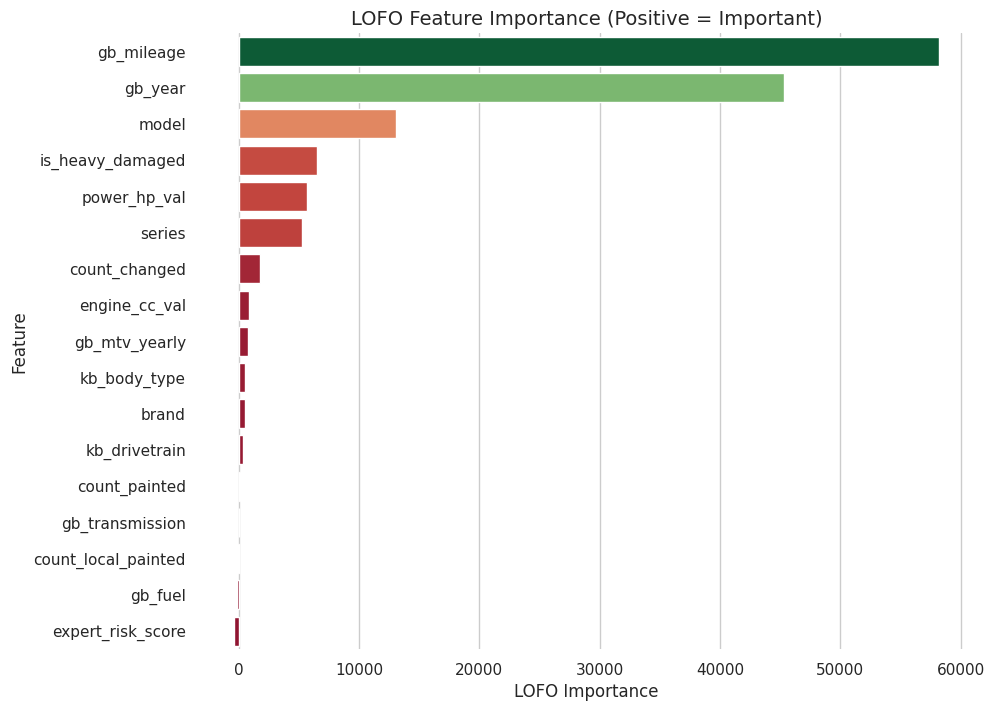

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi görselleştirmeden önce önem sırasına göre dizelim (Plotly'deki total ascending için)
lofo_results_sorted = lofo_results.sort_values('LOFO_Importance', ascending=False)

# Grafik boyutunu ve stilini ayarlayalım
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Barplot oluşturma
# 'palette' ile renk skalasını (RdYlGn benzeri) ayarlıyoruz
ax = sns.barplot(
    data=lofo_results_sorted,
    x='LOFO_Importance',
    y='Feature',
    hue='LOFO_Importance',      # Renklendirme için
    palette='RdYlGn',           # Kırmızı-Sarı-Yeşil skalası
    legend=False
)

# Başlık ve etiketler
plt.title('LOFO Feature Importance (Positive = Important)', fontsize=14)
plt.xlabel('LOFO Importance')
plt.ylabel('Feature')

# Gereksiz çizgileri temizleme (Plotly White temasına benzerlik için)
sns.despine(left=True, bottom=True)

plt.show()

In [39]:
import itertools
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool

print("--- Hierarchy Ablation Study: Combinations & CV ---")

# Define the base hierarchical features
base_features = ['brand', 'series', 'model']
hierarchy_feature_sets = []

# Generate all combinations of 1, 2, and 3 features
for r in range(1, len(base_features) + 1):
    hierarchy_feature_sets.extend([list(c) for c in itertools.combinations(base_features, r)])

ablation_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for feats in hierarchy_feature_sets:
    comb_name = " + ".join(feats)
    print(f"Evaluating: {comb_name}...")

    cv_rmses = []
    for train_idx, val_idx in kf.split(X_clean, y_clean):
        # Subset to only the selected features for this combination
        X_tr, X_va = X_clean.iloc[train_idx][feats], X_clean.iloc[val_idx][feats]
        y_tr, y_va = y_clean.iloc[train_idx], y_clean.iloc[val_idx]

        # Get dynamic indices for categorical and text features based on current subset
        c_idx = [feats.index(f) for f in cat_features if f in feats]
        t_idx = [feats.index(f) for f in text_features if f in feats]

        ab_train_pool = Pool(X_tr, y_tr, cat_features=c_idx, text_features=t_idx)
        ab_val_pool = Pool(X_va, y_va, cat_features=c_idx, text_features=t_idx)

        # Train CatBoost model
        ab_model = CatBoostRegressor(iterations=300, learning_rate=0.08, depth=6,
                                     loss_function='RMSE', verbose=False, random_seed=42, **gpu_params)
        ab_model.fit(ab_train_pool, eval_set=ab_val_pool)

        fold_rmse = np.sqrt(mean_squared_error(y_va, ab_model.predict(ab_val_pool)))
        cv_rmses.append(fold_rmse)

    mean_rmse = np.mean(cv_rmses)
    ablation_results.append({'Feature_Combination': comb_name, 'CV_RMSE': mean_rmse})

# Create DataFrame and display
ablation_df = pd.DataFrame(ablation_results).sort_values('CV_RMSE', ascending=False)
display(ablation_df)

# Visualize ablation combinations
fig_ablation = px.bar(
    ablation_df, x='CV_RMSE', y='Feature_Combination', orientation='h',
    title='Ablation Study: 5-Fold CV RMSE by Hierarchical Feature Combinations (Lower is Better)',
    color='CV_RMSE', color_continuous_scale='Blues_r', text_auto='.0f'
)
fig_ablation.update_layout(yaxis={'categoryorder':'total ascending'}, template="plotly_white")
fig_ablation.show()


--- Hierarchy Ablation Study: Combinations & CV ---
Evaluating: brand...
Evaluating: series...
Evaluating: model...
Evaluating: brand + series...
Evaluating: brand + model...
Evaluating: series + model...
Evaluating: brand + series + model...


,Feature_Combination,CV_RMSE
0,brand,1.042775e+06
1,series,9.451142e+05
3,brand + series,9.450829e+05
2,model,4.512768e+05
4,brand + model,4.503697e+05
6,brand + series + model,4.459154e+05
5,series + model,4.455466e+05


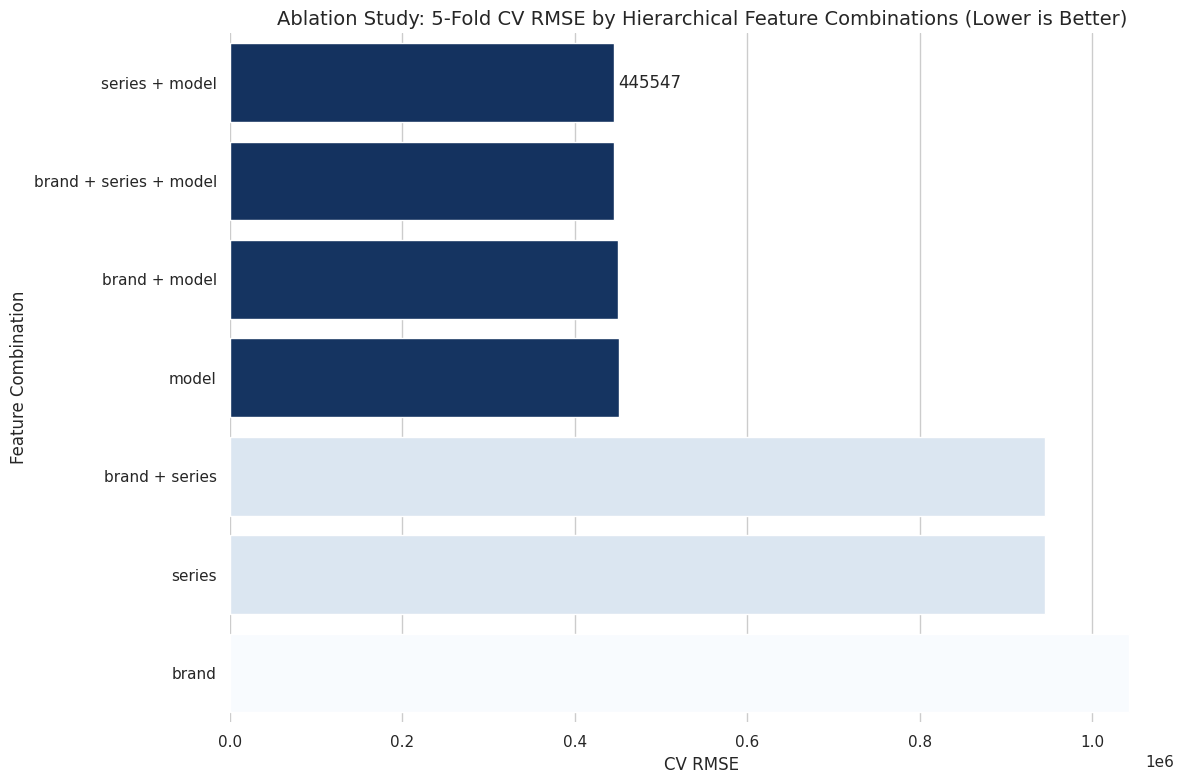

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi sıralayalım (Plotly'deki 'total ascending' için)
# RMSE düşükten büyüğe (en iyi sonuç en üstte kalacak şekilde) sıralanır
ablation_df_sorted = ablation_df.sort_values('CV_RMSE', ascending=True)

# 2. Grafik stilini ayarlayalım
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Barplot oluşturma
# 'palette' olarak 'Blues' (düşük değerler açık, yüksekler koyu)
# veya 'Blues_r' (tersi) kullanabilirsiniz.
ax = sns.barplot(
    data=ablation_df_sorted,
    x='CV_RMSE',
    y='Feature_Combination',
    hue='CV_RMSE',           # Renk skalası için
    palette='Blues_r',       # Plotly'deki Blues_r ile uyumlu
    legend=False
)

# 4. Çubukların üzerine değerleri yazdıma (text_auto='.0f' karşılığı)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)

# 5. Başlık ve etiketler
plt.title('Ablation Study: 5-Fold CV RMSE by Hierarchical Feature Combinations (Lower is Better)', fontsize=14)
plt.xlabel('CV RMSE')
plt.ylabel('Feature Combination')

# Gereksiz kenarlıkları kaldırarak Plotly White havası verelim
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Phase 7: Final Refined Model

### Subtask:
Train the final CatBoost model on the outlier-cleaned, cross-validated dataset using the optimal features. Output comparison metrics and save the model artifacts.

In [41]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool

# 1. We use the cleaned dataset from Phase 6 (X_clean, y_clean) directly as the target
# y_clean_log = np.log1p(y_clean) # Removed logarithm transformation

# Set up K-Fold Cross-Validation for the final evaluation
kf_final = KFold(n_splits=5, shuffle=True, random_state=42)
final_cv_scores = []
X_clean = X_clean.drop(columns = ["gb_fuel","gb_transmission"])
cat_features = [col for col in X_clean.select_dtypes(include=['object', 'category', 'bool']).columns if col not in text_features]
cat_indices = [X_clean.columns.get_loc(col) for col in cat_features]
print("--- Training Refined Final Model with 5-Fold CV (GPU) ---")
for fold, (train_idx, val_idx) in enumerate(kf_final.split(X_clean, y_clean)):
    X_tr, X_va = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
    y_tr, y_va = y_clean.iloc[train_idx], y_clean.iloc[val_idx] # Use original y_clean

    # Pools
    tr_pool = Pool(data=X_tr, label=y_tr, cat_features=cat_indices, text_features=text_indices)
    va_pool = Pool(data=X_va, label=y_va, cat_features=cat_indices, text_features=text_indices)

    # Initialize and fit CatBoostRegressor
    model_cv = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.05,
        depth=8,  # Slightly deeper for the final model to capture complex interactions
        loss_function='RMSE',
        eval_metric='RMSE',
        early_stopping_rounds=150,
        verbose=False,
        random_seed=42,
        **gpu_params
    )

    model_cv.fit(tr_pool, eval_set=va_pool)

    # Evaluate on validation set in original price scale for interpretable RMSE
    preds_price = model_cv.predict(va_pool) # Direct prediction, no expm1 needed
    y_va_price = y_va # Use original y_va

    rmse_price = np.sqrt(mean_squared_error(y_va_price, preds_price))
    final_cv_scores.append(rmse_price)
    print(f"Fold {fold + 1} RMSE (Price): {rmse_price:,.0f} TL")

print(f"\nFinal Cleaned CV RMSE: {np.mean(final_cv_scores):,.0f} TL (±{np.std(final_cv_scores):,.0f} TL)")

# 2. Train the Final Production Model on the entire clean dataset
final_full_pool = Pool(data=X_clean, label=y_clean, cat_features=cat_indices, text_features=text_indices) # Use original y_clean

final_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=250,
    random_seed=42,
    **gpu_params
)

print("\n--- Training Final Production Model on Full Clean Dataset ---")
final_model.fit(final_full_pool)

# 3. Save the model artifacts
model_filename = 'catboost_price_predictor_final.cbm'
final_model.save_model(model_filename)
print(f"\nSuccess: Final model saved as '{model_filename}'")

--- Training Refined Final Model with 5-Fold CV (GPU) ---
Fold 1 RMSE (Price): 142,988 TL
Fold 2 RMSE (Price): 137,344 TL
Fold 3 RMSE (Price): 138,810 TL
Fold 4 RMSE (Price): 137,884 TL
Fold 5 RMSE (Price): 135,478 TL

Final Cleaned CV RMSE: 138,501 TL (±2,493 TL)

--- Training Final Production Model on Full Clean Dataset ---
0:	learn: 999465.6109703	total: 18.2ms	remaining: 27.3s
250:	learn: 148304.0677714	total: 4.29s	remaining: 21.3s
500:	learn: 137700.4829686	total: 8.37s	remaining: 16.7s
750:	learn: 133015.6479159	total: 12.8s	remaining: 12.7s
1000:	learn: 130233.8410758	total: 17.2s	remaining: 8.58s
1250:	learn: 127973.3492347	total: 21.5s	remaining: 4.29s
1499:	learn: 126393.8429959	total: 25.7s	remaining: 0us

Success: Final model saved as 'catboost_price_predictor_final.cbm'


In [42]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Metrics for the last Validation Fold (Out-of-sample performance)
fold_mae = mean_absolute_error(y_va_price, preds_price)
fold_r2 = r2_score(y_va_price, preds_price)

print("-- Validation Metrics (Last CV Fold - Out-of-Sample) ---")
print(f"R² Score : {fold_r2:.4f}")
print(f"MAE      : {fold_mae:,.0f} TL\n")

# 2. Metrics for the Final Production Model (In-sample performance on full clean data)
preds_price_full = final_model.predict(final_full_pool) # Predictions are already in price scale
y_true_price = y_clean # Use original y_clean, no log transformation

full_mae = mean_absolute_error(y_true_price, preds_price_full)
full_r2 = r2_score(y_true_price, preds_price_full)

print("-- Final Model Metrics (Full Clean Dataset - In-Sample) ---")
print(f"R² Score : {full_r2:.4f}")
print(f"MAE      : {full_mae:,.0f} TL")

-- Validation Metrics (Last CV Fold - Out-of-Sample) ---
R² Score : 0.9825
MAE      : 103,333 TL

-- Final Model Metrics (Full Clean Dataset - In-Sample) ---
R² Score : 0.9856
MAE      : 94,797 TL
